# Notes:

## Notes 1. API Request Limitation

In [ ]:
# Set limits for API request
# To avoid restirction or failure

LIMITS = {
    "tfl":          {"per_min": 400, "per_day": 4000},   # 500/min - buffer
    "ticketmaster": {"per_min": 250, "per_day": 4000},   # 5000/day, - 1000 buffer
    "open_meteo":   {"per_min": 500, "per_day": 8000},   # 10000/day - 2000 buffer
}

## Notes 2. Calling API Keys from Google Secrets



In [ ]:
from google.colab import userdata
userdata.get('secretName')

##3 Setting: Runtime Type: CPU vs GPU vs TPU

Use **CPU** is all we need.

* Our tasks only does **API requests + pandas merges** — the bottleneck is network waiting, so GPU adds nothing.
GPU would waste our **free Colab quota** (computational cost) and **gets disconnected more often** (stability)

* **TPU is even less relevant** — it's built for large-scale TensorFlow/JAX neural network training, does nothing for API fetching, pandas, or sklearn, and often **needs extra setup for regular libraries**

* Tuesday's **LogReg / Random Forest** (74k rows) is also **a minutes-level CPU job** — no GPU/TPU needed either
— the 10-hour estimate was API waiting time, already eliminated by the new architecture

* If we add a neural network later, we can switch runtime anytime — no need to reserve now

---

Conclusion: **CPU** ✅ GPU ❌ TPU ❌ → keep **version "Latest"** → **Save** → **run from Cell 1**

# Definition of Static, Semi-Static and Dynamic Data:

We are aligning our resources (API and static data) into **three types of `Data layers`**:

1. **`Static data`: Does NOT change during the project.**
    
    Examples: station list, fare zones, lift counts, step-free facilities.
    
    >Fetched once, cached, and reused until submission.

2. **`Semi-static data`: changes slowly, on a scale of days.** = data expires in a certain amount of time

    Examples: planned closures (published days ahead), typical crowding curves (TFL statistical patterns, updated occasionally).
    
    > Refreshed once per working session at most; today's fetch is still valid tomorrow, but not next week.

3. **`Dynamic (real-time) data`: changes on a scale of minutes.**

    Examples: live lift outages, current line disruptions.
    
    > Fetched only at the moment it's needed (e.g. during the live demo).

---

* Why the layers matter?

    Each layer gets a different fetch schedule, which is how we stay far below API rate limits: static costs ~300 calls once, semi-static ~300 per day, dynamic ~2 per query.

* Reminder:

  **Dynamic features (e.g. lift status) still appear in the training data**, but **as a frozen value from snapshot day**.
  
  At demo time, the same columns are overwritten with live values. Training uses frozen data; the demo uses live data.

    [more details explained below in `Summary_Snapshot Rule`]

# Summary: Data Alignment Pipeline (W3 Phase 1)

* **Two dataframes / 两张核心表:**
- `stations_df` — station identity (who the station is) | 站点身份表
- `attributes_df` — aligned features (what the station is like) | 对齐后的属性特征表
---
* **Run order / 运行顺序:** Cell 1 → 10, top to bottom. API cells cache to disk(i.e. Google Drive) — re-running costs **0 API calls** after the first successful run.

  ⬇️ explanation
  
    * no cache to disk = every time we need to request API
    
       [analogy] every time we need to go to library in person, to borrow the same book

   * API cells cache to disk = we run one time and save it to drive, so for future adjustment we do NOT need to request from API all the time

      [analogy] we get a copy of the book when we visit the library every time, now we can read the copy at home

    🌟
    
    It's just to **save our API requests during experimenting stage** because we have so many limitation. The cache setting is **temporary**.
      
---

* **API keys:** stored in Colab Secrets (`TFL_APP_KEY`, `TICKETMASTER_API_KEY`) — Cell 1 reads them automatically. Grant notebook access when the popup appears. | key 已存 Colab Secrets,Cell 1 自动读取,弹窗时点允许访问。

---
* **⚠️ Snapshot rule / 快照纪律:** **freeze ONE snapshot on Monday (Cell 8)** → Phase 2–5 all load that same file. Do **NOT refresh mid-week**. Refresh restarts in W4 (Streamlit).

    ⬇️

    **Data Drift**: Many data are dynamic, they change everyday - this will mess and ruin the entire validation and evluation stage.

  🌟

  To make sure **training, validation and annotation are based on a fixed dataset**, otherwise the data has nothing valid to compare (=we will **NOT be able to tell** if the error is caused by the model or the changes in data).


## Cell 1 — Setup & config | 环境配置

✅

In [ ]:
# ============================================================
# CELL 1: Setup & Config | 环境与全局配置
# EN: Run this first, always. Creates the folder structure that
#     every later phase (models W3, Streamlit W4) reads from.
# 中文: 永远先跑这格。建立后续所有阶段(W3 建模、W4 Streamlit)
#       共用的目录结构。
# ============================================================
import os, json, time, datetime, pathlib, re
import requests
import pandas as pd

# EN: Mount Google Drive so data survives Colab runtime restarts.
# 中文: 挂载 Drive,数据不随 runtime 重启丢失(Colab 本地盘会被清空)。
try:
    from google.colab import drive, userdata
    drive.mount('/content/drive')
    DATA_DIR = pathlib.Path('/content/drive/MyDrive/SKIP/data')
    # EN: both keys live in Colab Secrets (left sidebar, key icon)
    # 中文: 两个 key 都存在 Colab Secrets 里(左侧边栏钥匙图标)
    TFL_KEY = userdata.get('TFL_APP_KEY')
    TM_KEY  = userdata.get('TICKETMASTER_API_KEY')
except Exception:
    # EN: local / non-Colab fallback | 中文: 非 Colab 环境的回退路径
    DATA_DIR = pathlib.Path('./data')
    TFL_KEY = os.environ.get('TFL_APP_KEY', '')
    TM_KEY  = os.environ.get('TICKETMASTER_API_KEY', '')

for sub in ['static', 'semi_static', 'snapshots', 'live_cache']:
    (DATA_DIR / sub).mkdir(parents=True, exist_ok=True)

print(f"Data directory ready: {DATA_DIR}")

Mounted at /content/drive
Data directory ready: /content/drive/MyDrive/SKIP/data


In [ ]:
# Quick Check: Verify API keys are loaded correctly
# 验证 API key 是否正确读取

# Check 1: key exists and is not empty
# 检查 1:key 存在且非空
assert TFL_KEY, "TFL_APP_KEY is empty — check Colab Secrets name and notebook access toggle. key 为空,检查 Secrets 名称和访问开关。"
print(f"TFL key loaded: {TFL_KEY[:6]}... (length {len(TFL_KEY)})")

if TM_KEY:
    print(f"Ticketmaster key loaded: {TM_KEY[:6]}... (length {len(TM_KEY)})")
else:
    print("Ticketmaster key not found — fine for this week, needed later. 未找到,本周不影响。")

# Check 2: key actually works — one real TfL call
# 检查 2:key 真的能用 —— 发一次真实请求
import requests as _rq
_r = _rq.get("https://api.tfl.gov.uk/Line/victoria", params={"app_key": TFL_KEY}, timeout=15)
if _r.status_code == 200:
    print("TFL key VERIFIED — API accepted the key. key 验证通过。")
elif _r.status_code in (401, 403, 429):
    raise RuntimeError(f"TFL key REJECTED (HTTP {_r.status_code}) — key is wrong or revoked. key 无效或已作废。")
else:
    print(f"Unexpected status {_r.status_code} — key likely fine, TfL may be having issues. key 大概率没问题,可能是 TfL 服务异常。")

TFL key loaded: 429b91... (length 32)
Ticketmaster key loaded: ki2JG3... (length 32)
TFL key VERIFIED — API accepted the key. key 验证通过。


## Cell 2 — Rate limiter | 全局限流器 (group decision: 400/min, 4000/day)

✅

In [ ]:
# ============================================================
# CELL 2: Rate limiter | 全局限流器
# EN: ALL API calls in ALL phases must go through api_get().
#     - 400/min for TfL (official 500, we keep a buffer)  [group decision]
#     - 4000/day for TfL (1000 kept as buffer)            [group decision]
#     - Daily counts are saved to disk, so a Colab runtime
#       restart does NOT reset today's quota tracking.
# 中文: 所有阶段的所有 API 调用必须走 api_get()。
#       - TfL 400 次/分钟(官方 500,留 buffer)[小组决定]
#       - TfL 4000 次/天(留 1000 buffer)[小组决定]
#       - 每日计数持久化到磁盘,runtime 重启不会清零。
# ============================================================
LIMITS = {
    'tfl':          {'per_min': 400, 'per_day': 4000},
    'ticketmaster': {'per_min': 250, 'per_day': 4000},   # official 5000/day
    'open_meteo':   {'per_min': 500, 'per_day': 8000},   # official 10000/day
}

class RateLimiter:
    def __init__(self, data_dir):
        self.counter_file = pathlib.Path(data_dir) / 'api_daily_counts.json'
        self.minute_log = {k: [] for k in LIMITS}
        self._load()

    def _load(self):
        today = datetime.date.today().isoformat()
        if self.counter_file.exists():
            saved = json.loads(self.counter_file.read_text())
            # EN: new day -> reset counts | 中文: 新的一天,计数清零
            self.daily = saved if saved.get('_date') == today else {'_date': today}
        else:
            self.daily = {'_date': today}

    def _save(self):
        self.counter_file.write_text(json.dumps(self.daily))

    def wait_and_count(self, api):
        cfg = LIMITS[api]
        used = self.daily.get(api, 0)
        if used >= cfg['per_day']:
            raise RuntimeError(
                f"[{api}] daily quota {cfg['per_day']} reached - STOP for today. "
                f"已达当日上限,今天不要再调这个 API。")
        now = time.time()
        # EN: keep only timestamps from the last 60s | 中文: 只保留最近 60 秒的调用记录
        self.minute_log[api] = [t for t in self.minute_log[api] if now - t < 60]
        if len(self.minute_log[api]) >= cfg['per_min']:
            wait = 60 - (now - self.minute_log[api][0]) + 0.1
            time.sleep(max(wait, 0))
        self.minute_log[api].append(time.time())
        self.daily[api] = used + 1
        self._save()

LIMITER = RateLimiter(DATA_DIR)

def api_get(api_name, url, params=None, max_retries=3):
    """EN: the ONLY function that touches the network.
       Throttle + 429 backoff + retry live in one place.
       中文: 全项目唯一的联网函数。限流、429 退避、重试都集中在这里。"""
    params = dict(params or {})
    if api_name == 'tfl' and TFL_KEY:
        params['app_key'] = TFL_KEY
    last_err = None
    for attempt in range(max_retries):
        LIMITER.wait_and_count(api_name)
        try:
            r = requests.get(url, params=params, timeout=30)
            if r.status_code == 429:
                # EN: provider throttled us anyway -> exponential backoff
                # 中文: 服务端仍限流 -> 指数退避后重试
                time.sleep(2 ** attempt * 2)
                continue
            r.raise_for_status()
            return r.json()
        except Exception as e:
            last_err = e
            time.sleep(2 ** attempt)
    raise RuntimeError(f"{url} failed after {max_retries} retries: {last_err}")

print("Rate limiter ready. Today's usage so far:", {k: v for k, v in LIMITER.daily.items() if k != '_date'})

Rate limiter ready. Today's usage so far: {}


## Cell 3 — DataFrame 1: station identity | 站点身份表

✅ **Static**

In [ ]:
# ============================================================
# CELL 3: DATAFRAME 1 - Station identity | 站点身份表

# EN: One row per tube station:
# 🌟   WHO the station is  🌟
#     Columns：
# 🌟  logical_id / name / name_key / fare_zone / line_ids / lat / lon 🌟


#     Built ONCE from the TfL StopPoint API, then always read
#     from disk -> 0 API calls on every later run.

# 中文: 每站一行,回答"这个站是谁"。
#       从 TfL StopPoint API 建一次,之后永远读本地文件,
#       后续每次运行 0 次 API 调用。
# ============================================================
REGISTRY_FILE = DATA_DIR / 'static' / 'station_registry.csv'

def normalise_name(name):
    """EN: 'Green Park Underground Station' -> 'green park', so the same
       station matches across datasets that spell it differently.
       中文: 统一站名写法,让不同数据集里写法不一致的同一个站能对上。"""
    n = str(name).lower().strip()
    for suffix in [' underground station', ' rail station', ' dlr station',
                   ' (london)', ' station']:
        if n.endswith(suffix):
            n = n[: -len(suffix)]
    n = re.sub(r"[^a-z0-9& ']+", ' ', n)      # EN: drop punctuation | 中文: 去标点
    return re.sub(r'\s+', ' ', n).strip()

def build_station_registry(force=False):
    if REGISTRY_FILE.exists() and not force:
        print("Registry loaded from disk (0 API calls). 从本地读取,零调用。")
        return pd.read_csv(REGISTRY_FILE)

    raw = api_get('tfl', 'https://api.tfl.gov.uk/StopPoint/Mode/tube')
    rows = []
    for sp in raw.get('stopPoints', []):
        # EN: only keep station-level entries (id starts 940GZZ) - the mode
        #     endpoint also returns platforms/entrances we don't want.
        # 中文: 只保留车站级条目(940GZZ 开头),过滤掉站台/出入口级别的噪音。
        if not str(sp.get('id', '')).startswith('940G'):
            continue
        zone = None
        for prop in sp.get('additionalProperties', []):
            if prop.get('key') == 'Zone':
                zone = prop.get('value')
        rows.append({
            # EN: hubNaptanCode groups multi-mode stations (tube+DLR+rail)
            #     under one physical station -> this is our logical key.
            # 中文: hubNaptanCode 把多模式车站(地铁+DLR+国铁)归并成
            #       同一个物理站 -> 用它做逻辑主键。
            'logical_id': sp.get('hubNaptanCode') or sp['id'],
            'naptan_tube': sp['id'],
            'station_name': sp.get('commonName', ''),
            'name_key': normalise_name(sp.get('commonName', '')),
            'fare_zone': zone,
            'line_ids': ';'.join(sorted(l['id'] for l in sp.get('lines', []))),
            'lat': sp.get('lat'), 'lon': sp.get('lon'),
        })
    df = (pd.DataFrame(rows)
            .drop_duplicates('naptan_tube')
            .sort_values('station_name')
            .reset_index(drop=True))
    df.to_csv(REGISTRY_FILE, index=False)
    print(f"Registry built and saved: {len(df)} stations. 已建表并保存。")
    return df

stations_df = build_station_registry()
stations_df.head()

Registry loaded from disk (0 API calls). 从本地读取,零调用。


,logical_id,naptan_tube,station_name,name_key,fare_zone,line_ids,lat,lon
0,940GZZLUACT,940GZZLUACT,Acton Town Underground Station,acton town,3,district;piccadilly,51.503057,-0.280462
1,940GZZLUADE,940GZZLUADE,Aldgate East Underground Station,aldgate east,1,district;hammersmith-city,51.515037,-0.072384
2,940GZZLUALD,940GZZLUALD,Aldgate Underground Station,aldgate,1,circle;metropolitan,51.514246,-0.075689
3,940GZZLUALP,940GZZLUALP,Alperton Underground Station,alperton,4,piccadilly,51.540627,-0.299610
4,HUBAMR,940GZZLUAMS,Amersham Underground Station,amersham,9,metropolitan,51.674126,-0.607714


## Cell 4 — Station-name resolver | 站名解析器 ('Green Park' → NaptanId)

✅

In [ ]:
# ============================================================
# CELL 4: Station-name resolver | 站名解析器

# EN: User types 'Green Park' (or a slightly wrong spelling) ->
#     we return the registry row. Exact match -> 🌟fuzzy match (>=0.90)🌟
#     -> otherwise raise, 🌟 NEVER silently pick a wrong station 🌟

#     This answers the meeting question:
# 🌟  "how does the model know which NaptanId 'Green Park' is?"🌟


# 中文: 用户输入 'Green Park'(甚至拼写略错)-> 返回对应站点行。
#       精确匹配 -> 模糊匹配(相似度>=0.90)-> 否则报错,
#       绝不静默乱配。这就是会议上"模型怎么知道 Green Park
#       对应哪个 NaptanId"的答案。
# ============================================================
import difflib

def resolve_station(user_text, registry=None):
    reg = stations_df if registry is None else registry
    key = normalise_name(user_text)
    exact = reg[reg['name_key'] == key]
    if len(exact):
        return exact.iloc[0]
    # EN: fuzzy fallback for typos | 中文: 拼写错误时的模糊回退
    candidates = difflib.get_close_matches(key, reg['name_key'].tolist(),
                                           n=1, cutoff=0.90)
    if candidates:
        row = reg[reg['name_key'] == candidates[0]].iloc[0]
        print(f"Fuzzy matched '{user_text}' -> '{row['station_name']}'. 模糊匹配,请人工确认。")
        return row
    raise KeyError(f"'{user_text}' not found - add to manual review list. "
                   f"未找到,请加入人工确认清单。")

# quick self-test | 快速自测
print(resolve_station('Green Park')['naptan_tube'])
print(resolve_station('green park underground station')['naptan_tube'])

940GZZLUGPK
940GZZLUGPK


In [ ]:
# Quick Check: Test 'Canary Wharf' because it has 4 NaptanID and only 1 works for `Crowding API`
cw = resolve_station('Canary Wharf')
print(cw['station_name'])
print('logical_id: ', cw['logical_id'])
print('naptan_tube:', cw['naptan_tube'])


print(resolve_station('canary warf')['naptan_tube'])   # check fuzzy spelling: wharf → warf

Canary Wharf Underground Station
logical_id:  HUBCAW
naptan_tube: 940GZZLUCYF
Fuzzy matched 'canary warf' -> 'Canary Wharf Underground Station'. 模糊匹配,请人工确认。
940GZZLUCYF


## Cell 5 — Crowding-ID verification | Crowding 可用 ID 校验 (Canary Wharf problem)

✅ **STATIC**

Findings:

* 270/272 got verified.

* Two stations requires manual id lookup:
   1. **Hammersmith (Dist&Picc Line) Underground Station**
   2. **Monument Underground Station**
  
  Why？
  *   There are **two stations in Hammersmith** and **TFL combined them into one**: Hammersmith & City and District & Piccadilly. The stations are opposite to each other, across street.
  
  *   **Monument is combined with Bank**: Monument is connected with Bank, so TFl defined it as "Bank-Monument complex" instead of two separate station


  🛠️
  updated manual check codes to `CELL 5 + Manual Check`

> For Hammersmith line, I changed there every day during my degrees, and went there few months ago. It is true.

> "Bank and Monument form a single interchange complex operated as one station (TfL; Wikipedia, "Bank and Monument stations"). Consistent with this, the TfL Crowding endpoint returned no data for Monument's own NaptanId (940GZZLUMMT) but valid data under Bank's ID — verified empirically on `CELL 5 + Manual Check`."
[proof archived in Teams, 06 July 2026, 01:41]

⬇️

`CELL 5` + `CELL 5 Manual Check` is now updated and intergreted into `CELL 5.v2`

In [ ]:
# ✅ CELL 5.v2

# ============================================================
# CELL 5: Crowding-ID verification | Crowding 可用 ID 校验
# 自动校验 272 站 + 内置 2 个已验证的人工修补
# Auto-verify all stations + 2 built-in manual fixes (verified 06 Jul 2026)
# ============================================================
VERIFIED_FILE = DATA_DIR / 'static' / 'crowding_verified_ids.csv'

# 自动校验失败、经人工诊断和 API 实测确认的替代 ID
# Manually diagnosed substitutes, each confirmed by a real API call:
#   Monument: 与 Bank 同属一个联合体,数据挂在 Bank 名下
#             one interchange complex with Bank; data lives under Bank's id
#   Hammersmith (D&P): 马路对面 H&C 站的数据作为近似 —— 已记录的假设,需写进报告
#             proxy from the H&C station across the road — documented assumption
MANUAL_CROWDING = {
    'Monument Underground Station': '940GZZLUBNK',
    'Hammersmith (Dist&Picc Line) Underground Station': '940GZZLUHSC',
}

def crowding_works(naptan_id):
    # 该 id 能从 Crowding API 拿到有效数据则返回 True
    # True if the Crowding API returns usable data for this id
    try:
        js = api_get('tfl', f'https://api.tfl.gov.uk/crowding/{naptan_id}')
        return bool(js.get('daysOfWeek'))
    except Exception:
        return False

def verify_crowding_ids(registry, force=False):
    if VERIFIED_FILE.exists() and not force:
        print("Verified ids loaded from disk (0 API calls). 从本地读取,零调用。")
        return pd.read_csv(VERIFIED_FILE)

    # 第一轮:每站用自己的 tube id 试一次
    # Pass 1: try each station's own tube id once
    rows = []
    for _, st in registry.iterrows():
        ok = crowding_works(st['naptan_tube'])
        rows.append({'logical_id': st['logical_id'],
                     'naptan_tube': st['naptan_tube'],
                     'crowding_id': st['naptan_tube'] if ok else None,
                     'crowding_ok': ok})
    df = pd.DataFrame(rows)

    # 第二轮:对失败的站应用人工替代 ID,每个仍需真实 API 验证后才写入
    # Pass 2: apply manual substitutes to failures — each must pass a real
    # API check before being recorded, so a wrong substitute can't slip in
    for name, candidate in MANUAL_CROWDING.items():
        target = registry.loc[registry['station_name'] == name, 'naptan_tube']
        if target.empty:
            continue
        if crowding_works(candidate):
            mask = df['naptan_tube'].isin(target)
            df.loc[mask, ['crowding_id', 'crowding_ok']] = [candidate, True]
            print(f"Manual fix applied: {name} -> {candidate}")
        else:
            print(f"Manual fix FAILED for {name} -> {candidate}, left unresolved")

    df.to_csv(VERIFIED_FILE, index=False)
    bad = df[~df['crowding_ok']]
    print(f"Verified {df['crowding_ok'].sum()}/{len(df)} stations. "
          f"{len(bad)} unresolved. 未解决的站:")
    if len(bad):
        print(bad.merge(registry[['naptan_tube','station_name']],
                        on='naptan_tube')['station_name'].tolist())
    return df

crowding_ids = verify_crowding_ids(stations_df)

print(crowding_ids['crowding_ok'].sum(), '/', len(crowding_ids))
print(crowding_ids[crowding_ids['naptan_tube'] == '940GZZLUMMT'])   # Monument

Verified ids loaded from disk (0 API calls). 从本地读取,零调用。
272 / 272
      logical_id  naptan_tube  crowding_id  crowding_ok
149  940GZZLUMMT  940GZZLUMMT  940GZZLUBNK         True


In [ ]:
# 🚨 270/272
# ============================================================
# CELL 5: Crowding-ID verification | Crowding 可用 ID 校验
# Which of these IDs this specific API — Crowding — actually recognise

# EN: Some stations (Canary Wharf!) have several NaptanIds and only
#     one works with the Crowding API. We try each candidate ONCE,
#     save the working one to disk. First run costs ~300-600 calls;
#     every later run costs 0.

# 中文: 部分站(如 Canary Wharf)有多个 NaptanId,Crowding API 只认
#       其中一个。每个候选只试一次,把能用的存盘。首跑约消耗
#       300-600 次调用,以后每次运行 0 次。
# ============================================================
VERIFIED_FILE = DATA_DIR / 'static' / 'crowding_verified_ids.csv'

def crowding_works(naptan_id):
    """EN: True if the Crowding API returns usable data for this id.
       中文: 该 id 能从 Crowding API 拿到有效数据则返回 True。"""
    try:
        js = api_get('tfl', f'https://api.tfl.gov.uk/crowding/{naptan_id}')
        return bool(js.get('daysOfWeek'))
    except Exception:
        return False

def verify_crowding_ids(registry, force=False):
    if VERIFIED_FILE.exists() and not force:
        print("Verified ids loaded from disk (0 API calls). 从本地读取,零调用。")
        return pd.read_csv(VERIFIED_FILE)
    rows = []
    for _, st in registry.iterrows():
        ok = crowding_works(st['naptan_tube'])
        rows.append({'logical_id': st['logical_id'],
                     'naptan_tube': st['naptan_tube'],
                     'crowding_id': st['naptan_tube'] if ok else None,
                     'crowding_ok': ok})
    df = pd.DataFrame(rows)
    df.to_csv(VERIFIED_FILE, index=False)
    bad = df[~df['crowding_ok']]
    print(f"Verified {df['crowding_ok'].sum()}/{len(df)} stations. "
          f"{len(bad)} need manual id lookup. 未通过的站需人工查替代 ID:")
    print(bad.merge(registry[['naptan_tube','station_name']], on='naptan_tube')
             ['station_name'].tolist()[:15])
    return df

crowding_ids = verify_crowding_ids(stations_df)

Verified 270/272 stations. 2 need manual id lookup. 未通过的站需人工查替代 ID:
['Hammersmith (Dist&Picc Line) Underground Station', 'Monument Underground Station']


In [ ]:
# 🛠️
# CELL 5 + Manual Check
# Manual fixes for the 2 stations Crowding API rejected
# 人工修补 Crowding API 不认的 2 个站
manual_crowding = {
    # Monument shares one complex with Bank -> use Bank's id
    # Monument 和 Bank 是同一个联合体 -> 用 Bank 的 ID
    'Monument Underground Station': '940GZZLUBNK',
    # Two separate Hammersmith stations across the road;
    # use the H&C station's data as a proxy (documented assumption)
    # Hammersmith 是马路两侧的两个站,用 H&C 站的数据作为近似(已记录的假设)
    'Hammersmith (Dist&Picc Line) Underground Station': '940GZZLUHSC',
}

for name, candidate_id in manual_crowding.items():
    ok = crowding_works(candidate_id)          # 1 API call each
    print(f"{name} -> {candidate_id}: {'WORKS' if ok else 'STILL FAILS'}")
    if ok:
        mask = crowding_ids['naptan_tube'].isin(
            stations_df.loc[stations_df['station_name'] == name, 'naptan_tube'])
        crowding_ids.loc[mask, ['crowding_id', 'crowding_ok']] = [candidate_id, True]

crowding_ids.to_csv(VERIFIED_FILE, index=False)   # overwrite the cache
print(f"Now verified: {crowding_ids['crowding_ok'].sum()}/272")

Monument Underground Station -> 940GZZLUBNK: WORKS
Hammersmith (Dist&Picc Line) Underground Station -> 940GZZLUHSC: WORKS
Now verified: 272/272


In [ ]:
# Both Hammersmith stations side by side
# 找出两个 Hammersmith,对照看
hsm = stations_df[stations_df['name_key'].str.contains('hammersmith')]
print(hsm[['station_name', 'naptan_tube']])

# Their rows in the verified table
# 再看它们在 crowding_ids 里的记录
print(crowding_ids[crowding_ids['naptan_tube'].isin(hsm['naptan_tube'])])

                                        station_name  naptan_tube
95  Hammersmith (Dist&Picc Line) Underground Station  940GZZLUHSD
96        Hammersmith (H&C Line) Underground Station  940GZZLUHSC
   logical_id  naptan_tube  crowding_id  crowding_ok
95     HUBHMS  940GZZLUHSD  940GZZLUHSC         True
96     HUBHMS  940GZZLUHSC  940GZZLUHSC         True


## Cell 6 — DataFrame 2 Part A: API features | API 特征


✅ **Semi-Static Data**

✅ perfectly clean

Explanation of the Results `272 272 272`:

* `crowding_feat` = 272 rows:

    AM/PM peak crowding per station (Monument uses Bank's data; the two Hammersmith stations share the H&C station's data)

* `closure_feat` = 272 rows:

    has_planned_closure per station, derived from today's line status


* `lift_feat` = 272 rows:

    has_live_lift_issue per station, from the live lift disruption v2 feed

---

* Code requires adjustment after adjustment on `CELL 7.v2` and bug revealed in `Quick Check before CELL 8`, therefore now updated to `CELL 6.v3`.

In [ ]:
# 🛠️ CELL 6.v3

# ============================================================
# CELL 6.v3: DATAFRAME 2 part A - semi-static attributes from APIs
#            属性表 A 部分 - 来自 API 的半静态特征
#
# v2 changes | v2 改动:
#   Output key logical_id -> naptan_tube (unique per row); hub
#   stations (HUBHMS) repeat logical_id and duplicated rows 272->300.
#   输出键改为 naptan_tube(每行唯一);hub 站的 logical_id 重复,
#   曾导致行数膨胀 272->300。
#
# v3 changes | v3 改动:
#   Planned-closure detection now EXACT-matches real closure statuses.
#   The old substring test ('Closed' in desc) wrongly flagged
#   'Service Closed' - the normal overnight state - so a late-night
#   run marked all 272 stations as closed. Caught by the pre-freeze QC.
#   计划关闭检测改为精确匹配真实关闭状态。旧的子串匹配把夜间正常
#   收班的 'Service Closed' 误判为关闭,深夜运行时 272 站全部标 1。
#   该问题由冻结前质检发现。
# ============================================================

# Purge the v1 cache (stored with logical_id) if it still exists
# 若 v1 旧缓存(logical_id 键)仍存在则清除
_old = DATA_DIR / 'semi_static' / 'crowding_features.csv'
if _old.exists():
    _old.unlink()
    print("v1 cache purged. 已清除 v1 旧缓存。")

def fetch_crowding_features(crowding_ids_df):
    """Average weekday AM-peak and PM-peak crowding per station.
    每站工作日早/晚高峰拥挤度均值(相对基线的百分比)。"""
    cache = DATA_DIR / 'semi_static' / 'crowding_features_v2.csv'
    if cache.exists():
        print("Crowding features loaded from disk (0 API calls). 从本地读取,零调用。")
        return pd.read_csv(cache)
    rows = []
    ok_ids = crowding_ids_df[crowding_ids_df['crowding_ok']]
    for _, st in ok_ids.iterrows():
        js = api_get('tfl', f"https://api.tfl.gov.uk/crowding/{st['crowding_id']}")
        am, pm = [], []
        for day in js.get('daysOfWeek', []):
            if day.get('dayOfWeek') in ('MON','TUE','WED','THU','FRI'):
                for band in day.get('timeBands', []):
                    pct = band.get('percentageOfBaseLine')
                    t = str(band.get('timeBand', ''))
                    if pct is None:
                        continue
                    # AM peak 07:00-10:00, PM peak 16:00-19:00
                    # 早高峰 07-10 点,晚高峰 16-19 点
                    if t.startswith(('07','08','09')):
                        am.append(pct)
                    elif t.startswith(('16','17','18')):
                        pm.append(pct)
        rows.append({'naptan_tube': st['naptan_tube'],
                     'crowding_peak': sum(am)/len(am) if am else None,
                     'crowding_evening': sum(pm)/len(pm) if pm else None})
    df = pd.DataFrame(rows)
    df.to_csv(cache, index=False)
    return df

def fetch_planned_closures(registry):
    """has_planned_closure per station: a station inherits a closure
    if ANY line serving it has a genuine planned closure.
    站点级计划关闭:该站任一线路有真实计划关闭则为 1。

    v3: EXACT match only. 'Service Closed' (normal overnight shutdown)
    must NOT count as a closure.
    v3:仅精确匹配。'Service Closed'(夜间正常收班)不算关闭。"""
    PLANNED = {'Planned Closure', 'Part Closure'}
    js = api_get('tfl', 'https://api.tfl.gov.uk/Line/Mode/tube/Status')
    closed_lines = set()
    for line in js:
        for s in line.get('lineStatuses', []):
            if s.get('statusSeverityDescription') in PLANNED:
                closed_lines.add(line['id'])
    def station_flag(line_ids):
        return int(any(l in closed_lines for l in str(line_ids).split(';')))
    out = registry[['naptan_tube', 'line_ids']].copy()
    out['has_planned_closure'] = out['line_ids'].map(station_flag)
    return out[['naptan_tube', 'has_planned_closure']]

def fetch_lift_issues(registry):
    """has_live_lift_issue from Lift Disruptions v2; the API returns
    station names, so we match on the normalised name_key.
    电梯故障实况;该 API 返回站名,用归一化 name_key 匹配。"""
    js = api_get('tfl', 'https://api.tfl.gov.uk/Disruptions/Lifts/v2')
    affected = set()
    for item in (js if isinstance(js, list) else []):
        name = item.get('stationName') or item.get('commonName') or ''
        if name:
            affected.add(normalise_name(name))
    out = registry[['naptan_tube', 'name_key']].copy()
    out['has_live_lift_issue'] = out['name_key'].isin(affected).astype(int)
    return out[['naptan_tube', 'has_live_lift_issue']]

crowding_feat = fetch_crowding_features(crowding_ids)
closure_feat  = fetch_planned_closures(stations_df)
lift_feat     = fetch_lift_issues(stations_df)

# Key sanity check - all three must carry the unique key
# 键自检 - 三张表必须都带唯一键
for _n, _d in [('crowding', crowding_feat), ('closure', closure_feat), ('lift', lift_feat)]:
    assert 'naptan_tube' in _d.columns, f"{_n} still on old key! {_n} 仍是旧键!"
print(len(crowding_feat), len(closure_feat), len(lift_feat), "- all keyed on naptan_tube")
print("closure flag distribution 关闭标记分布:",
      dict(closure_feat['has_planned_closure'].value_counts()))

Crowding features loaded from disk (0 API calls). 从本地读取,零调用。
272 272 272 - all keyed on naptan_tube
closure flag distribution 关闭标记分布: {0: np.int64(272)}


In [ ]:
# ❌ Caught bug after running `Quick Check before CELL 8`
# ============================================================
# CELL 6.v2: DATAFRAME 2 part A - semi-static attributes from APIs
#            属性表 A 部分 - 来自 API 的半静态特征
#
# v2 changes | v2 改动:
#   Output key changed logical_id -> naptan_tube (unique per row).
#   logical_id repeats at hub stations (HUBHMS) and caused row
#   duplication downstream (272 -> 300).
#   输出键从 logical_id 改为 naptan_tube(每行唯一)。
#   logical_id 在 hub 站会重复,导致下游行数膨胀(272 -> 300)。
#   Old v1 cache is auto-purged so new code actually runs.
#   自动清除 v1 旧缓存,确保新代码真正执行。
# ============================================================

# Purge the v1 cache (stored with logical_id) once
# 清除一次 v1 旧缓存(它是用 logical_id 存的)
_old = DATA_DIR / 'semi_static' / 'crowding_features.csv'
if _old.exists():
    _old.unlink()
    print("v1 cache purged, will re-fetch with new schema. 已清除旧缓存,将按新结构重新抓取。")

def fetch_crowding_features(crowding_ids_df):
    """Average weekday AM-peak and PM-peak crowding per station.
    每站工作日早/晚高峰拥挤度均值(相对基线的百分比)。"""
    cache = DATA_DIR / 'semi_static' / 'crowding_features_v2.csv'
    if cache.exists():
        print("Crowding features loaded from disk (0 API calls). 从本地读取,零调用。")
        return pd.read_csv(cache)
    rows = []
    ok_ids = crowding_ids_df[crowding_ids_df['crowding_ok']]
    for _, st in ok_ids.iterrows():
        js = api_get('tfl', f"https://api.tfl.gov.uk/crowding/{st['crowding_id']}")
        am, pm = [], []
        for day in js.get('daysOfWeek', []):
            if day.get('dayOfWeek') in ('MON','TUE','WED','THU','FRI'):
                for band in day.get('timeBands', []):
                    pct = band.get('percentageOfBaseLine')
                    t = str(band.get('timeBand', ''))
                    if pct is None:
                        continue
                    # AM peak 07:00-10:00, PM peak 16:00-19:00
                    # 早高峰 07-10 点,晚高峰 16-19 点
                    if t.startswith(('07','08','09')):
                        am.append(pct)
                    elif t.startswith(('16','17','18')):
                        pm.append(pct)
        rows.append({'naptan_tube': st['naptan_tube'],
                     'crowding_peak': sum(am)/len(am) if am else None,
                     'crowding_evening': sum(pm)/len(pm) if pm else None})
    df = pd.DataFrame(rows)
    df.to_csv(cache, index=False)
    return df

def fetch_planned_closures(registry):
    """has_planned_closure per station: a station inherits a closure
    if ANY line serving it has one.
    站点级计划关闭:该站任一线路有计划关闭则为 1。"""
    js = api_get('tfl', 'https://api.tfl.gov.uk/Line/Mode/tube/Status')
    closed_lines = set()
    for line in js:
        for s in line.get('lineStatuses', []):
            desc = str(s.get('statusSeverityDescription', ''))
            if 'Closure' in desc or 'Closed' in desc:
                closed_lines.add(line['id'])
    def station_flag(line_ids):
        return int(any(l in closed_lines for l in str(line_ids).split(';')))
    out = registry[['naptan_tube', 'line_ids']].copy()
    out['has_planned_closure'] = out['line_ids'].map(station_flag)
    return out[['naptan_tube', 'has_planned_closure']]

def fetch_lift_issues(registry):
    """has_live_lift_issue from Lift Disruptions v2; the API returns
    station names, so we match on the normalised name_key.
    电梯故障实况;该 API 返回站名,用归一化 name_key 匹配。"""
    js = api_get('tfl', 'https://api.tfl.gov.uk/Disruptions/Lifts/v2')
    affected = set()
    for item in (js if isinstance(js, list) else []):
        name = item.get('stationName') or item.get('commonName') or ''
        if name:
            affected.add(normalise_name(name))
    out = registry[['naptan_tube', 'name_key']].copy()
    out['has_live_lift_issue'] = out['name_key'].isin(affected).astype(int)
    return out[['naptan_tube', 'has_live_lift_issue']]

crowding_feat = fetch_crowding_features(crowding_ids)
closure_feat  = fetch_planned_closures(stations_df)
lift_feat     = fetch_lift_issues(stations_df)

# Key sanity check - all three must carry the unique key
# 键自检 - 三张表必须都带唯一键
for _n, _d in [('crowding', crowding_feat), ('closure', closure_feat), ('lift', lift_feat)]:
    assert 'naptan_tube' in _d.columns, f"{_n} still on old key! {_n} 仍是旧键!"
print(len(crowding_feat), len(closure_feat), len(lift_feat), "- all keyed on naptan_tube")

v1 cache purged, will re-fetch with new schema. 已清除旧缓存,将按新结构重新抓取。
272 272 272 - all keyed on naptan_tube


In [ ]:
# ❌ Requires update after testing Cell 7
# ============================================================
# CELL 6: DATAFRAME 2 part A - semi-static attributes from APIs
#          | 属性表 A 部分 - 来自 API 的半静态特征

# EN: crowding_peak / crowding_evening / has_planned_closure /
#     has_live_lift_issue. Each fetcher returns a small dataframe
#     keyed by logical_id, ready to merge.

# 中文: 每个抓取函数返回一个以 logical_id 为键的小表,直接可 merge。
# ============================================================

def fetch_crowding_features(crowding_ids_df):
    """EN: average weekday AM-peak and PM-peak crowding percentage.
       中文: 工作日早/晚高峰拥挤度均值(相对基线的百分比)。"""
    cache = DATA_DIR / 'semi_static' / 'crowding_features.csv'
    if cache.exists():
        return pd.read_csv(cache)
    rows = []
    ok_ids = crowding_ids_df[crowding_ids_df['crowding_ok']]
    for _, st in ok_ids.iterrows():
        js = api_get('tfl', f"https://api.tfl.gov.uk/crowding/{st['crowding_id']}")
        am, pm = [], []
        for day in js.get('daysOfWeek', []):
            if day.get('dayOfWeek') in ('MON','TUE','WED','THU','FRI'):
                for band in day.get('timeBands', []):
                    pct = band.get('percentageOfBaseLine')
                    t = str(band.get('timeBand', ''))
                    if pct is None:
                        continue
                    # EN: AM peak 07:00-10:00, PM peak 16:00-19:00
                    # 中文: 早高峰 07-10 点,晚高峰 16-19 点
                    if t.startswith(('07','08','09')):
                        am.append(pct)
                    elif t.startswith(('16','17','18')):
                        pm.append(pct)
        rows.append({'logical_id': st['logical_id'],
                     'crowding_peak': sum(am)/len(am) if am else None,
                     'crowding_evening': sum(pm)/len(pm) if pm else None})
    df = pd.DataFrame(rows)
    df.to_csv(cache, index=False)
    return df

def fetch_planned_closures(registry):
    """EN: has_planned_closure per station, derived from line status:
       a station inherits a closure if ANY line serving it has one.
       中文: 站点级 has_planned_closure:该站任一线路有计划关闭则为 1。"""
    js = api_get('tfl', 'https://api.tfl.gov.uk/Line/Mode/tube/Status')
    closed_lines = set()
    for line in js:
        for s in line.get('lineStatuses', []):
            desc = str(s.get('statusSeverityDescription', ''))
            if 'Closure' in desc or 'Closed' in desc:
                closed_lines.add(line['id'])
    def station_flag(line_ids):
        return int(any(l in closed_lines for l in str(line_ids).split(';')))
    out = registry[['logical_id', 'line_ids']].copy()
    out['has_planned_closure'] = out['line_ids'].map(station_flag)
    return out[['logical_id', 'has_planned_closure']]

def fetch_lift_issues(registry):
    """EN: has_live_lift_issue from Lift Disruptions v2. The API returns
       station names, so we match on the normalised name_key.
       中文: 电梯故障实况。该 API 返回站名,用归一化 name_key 匹配。"""
    js = api_get('tfl', 'https://api.tfl.gov.uk/Disruptions/Lifts/v2')
    affected = set()
    for item in (js if isinstance(js, list) else []):
        name = item.get('stationName') or item.get('commonName') or ''
        if name:
            affected.add(normalise_name(name))
    out = registry[['logical_id', 'name_key']].copy()
    out['has_live_lift_issue'] = out['name_key'].isin(affected).astype(int)
    return out[['logical_id', 'has_live_lift_issue']]

crowding_feat = fetch_crowding_features(crowding_ids)
closure_feat  = fetch_planned_closures(stations_df)
lift_feat     = fetch_lift_issues(stations_df)
print(len(crowding_feat), len(closure_feat), len(lift_feat))

272 272 272


## Cell 7 — DataFrame 2 Part B: static-file features + final merge | 静态文件特征与总合并

Findings:

* ❌ `CELL 7`'s outcome is: 300 rows x 17 columns, apparently wrong.

    ⬇️
    
    = data from Hub stations (like Hammersmith) got merged

    🛠️
    
    Code updated to `CELL 7.v2`

* `<NA>` content will be updated later, the NAN value is temporary.








**Resources: Where does those two emerged .csv come from?**

**Source** : TfL official Station facilities dataset (XML/KML feed, © Transport for London)：

lrad-v2.xml (dedicated step-free dataset) → not retrievable at collection time → facilities feed used instead



---


**Output**: 2 engineered CSVs

1. `facilities.csv` → lift_count, step_free_platform_count, accessible_toilet_count

2. `step_free_lrad.csv` → ramp_platform_count, mean_gap_mm, accessibility_type


---

**Methodology: why not the raw TfL file directly ?**

Raw = single nested XML, keyed by station name → no NaPTAN IDs → cannot join to our registry
Values = free text ("yes", "0 on platforms, 0 in ticket halls") → not numeric
One record can span multiple platforms/entrances → not one-row-per-station

**What we did?**

Parsed XML once → aggregated to one row per station
Free text → numeric counts
Station names → matched via normalised name_key → stored keyed on naptan_tube (primary key) → exact, assert-guarded merges

---

**Known limitations** (report honestly):

* `accessibility_type (0–3)` = derived proxy, not TfL's official step-free classification

* `mean_gap_mm sparse in source (106/270)` → NA-aware scoring skips per-route, no imputation

* `270/272 matched` → Battersea Power Station & Nine Elms (2021) post-date source → left as NA

* **Feed published 2010** → counts may lag current stations → OK for training snapshot, flag for refresh in W4

In [ ]:
# Verify the two static CSVs are in the right place
# two static CSV was the combined dataset based on 'tfl-stationdata-detailed'

# 确认两份静态 CSV 位置正确
import pathlib

for fname in ['facilities.csv', 'step_free_lrad.csv']:
    p = DATA_DIR / 'static' / fname
    if p.exists():
        import pandas as pd
        df = pd.read_csv(p)
        print(f"FOUND {fname}: {len(df)} rows, columns = {list(df.columns)}")
    else:
        print(f"MISSING at expected path: {p}")
        # search the whole SKIP folder in case it landed elsewhere
        # 全 SKIP 文件夹搜索,看是不是传错了位置
        hits = list(pathlib.Path('/content/drive/MyDrive').rglob(fname))
        print(f"  found elsewhere: {[str(h) for h in hits] or 'nowhere - not uploaded yet 未找到'}")

FOUND facilities.csv: 270 rows, columns = ['naptan_tube', 'lift_count', 'step_free_platform_count', 'accessible_toilet_count']
FOUND step_free_lrad.csv: 270 rows, columns = ['naptan_tube', 'ramp_platform_count', 'mean_gap_mm', 'accessibility_type']


In [ ]:
# 17 Column Titles in CELL 7.v2 Output

# ============================================================
# Schema reference: attributes_df (17 columns)
# 属性表列说明(会议展示用)
# ============================================================
# Colour = data layer:
# green = static
# yellow = semi-static
# red = dynamic

# Placeholder = NAN value atm, but will be filled in the later stage
# PAC_score is in white because it does NOT belong to any `data layer`, it's the predicted label (y) our model gonna compute

# 颜色 = 数据层:绿 = 静态 | 黄 = 半静态 | 红 = 动态
# ============================================================
import pandas as pd
from IPython.display import display, HTML

SCHEMA = [
    ('logical_id',               'Identity',    'static',      'TfL hub code; groups multi-identity stations',   'registry (Cell 3)',            'filled'),
    ('naptan_tube',              'Identity',    'static',      'Unique tube station id - PRIMARY KEY',           'registry (Cell 3)',            'filled'),
    ('station_name',             'Identity',    'static',      'Official full name',                             'registry (Cell 3)',            'filled'),
    ('name_key',                 'Identity',    'static',      'Normalised name for matching',                   'registry (Cell 3)',            'filled'),
    ('fare_zone',                'Identity',    'static',      'Fare zone 1-9',                                  'registry (Cell 3)',            'filled'),
    ('lift_count',               'Facility',    'static',      'Number of lifts',                                'facilities.csv',               'filled'),
    ('step_free_platform_count', 'Facility',    'static',      'Step-free platforms',                            'facilities.csv',               'filled'),
    ('accessible_toilet_count',  'Facility',    'static',      'Accessible toilets',                             'facilities.csv',               'filled'),
    ('accessibility_type',       'Facility',    'static',      'Accessibility level 0-3',                        'step_free_lrad.csv',           'filled'),
    ('ramp_platform_count',      'Facility',    'static',      'Platforms with ramps',                           'step_free_lrad.csv',           'filled'),
    ('mean_gap_mm',              'Facility',    'static',      'Mean train-platform gap (mm)',                   'step_free_lrad.csv',           'filled'),
    ('crowding_peak',            'API feature', 'semi-static', 'Weekday AM-peak crowding vs baseline',           'Crowding API (Cell 6)',        'filled'),
    ('crowding_evening',         'API feature', 'semi-static', 'Weekday PM-peak crowding vs baseline',           'Crowding API (Cell 6)',        'filled'),
    ('has_planned_closure',      'API feature', 'semi-static', 'Any serving line has planned closure (0/1)',     'Line Status API (Cell 6)',     'filled'),
    ('has_live_lift_issue',      'API feature', 'dynamic',     'Live lift outage now (0/1), frozen at snapshot', 'Lift Disruptions v2 (Cell 6)', 'filled'),
    ('predicted_temp_c',         'Placeholder', 'semi-static', 'SARIMA carriage temperature forecast',           'SARIMA (Phase 2)',             'filled (SARIMA v1)'),
    ('pac_score',                'Placeholder', '-',           'PAC label, computed by team',                    'team (Phase 2+)',              'empty by design'),
]
schema_df = pd.DataFrame(SCHEMA, columns=['column', 'group', 'data_layer', 'meaning', 'source', 'status'])

LAYER_COLOURS = {'static': '#e6f4ea', 'semi-static': '#fef7e0', 'dynamic': '#fce8e6', '-': '#ffffff'}

display(HTML(
    "<b>Legend | 图例:</b> "
    "<span style='background:#e6f4ea;padding:2px 8px'>static - fetched once</span> "
    "<span style='background:#fef7e0;padding:2px 8px'>semi-static - refreshed daily</span> "
    "<span style='background:#fce8e6;padding:2px 8px'>dynamic - live, frozen at snapshot</span>"))

(schema_df.style
    .apply(lambda r: [f'background-color: {LAYER_COLOURS[r["data_layer"]]}'] * len(r), axis=1)
    .hide(axis='index'))

column,group,data_layer,meaning,source,status
logical_id,Identity,static,TfL hub code; groups multi-identity stations,registry (Cell 3),filled
naptan_tube,Identity,static,Unique tube station id - PRIMARY KEY,registry (Cell 3),filled
station_name,Identity,static,Official full name,registry (Cell 3),filled
name_key,Identity,static,Normalised name for matching,registry (Cell 3),filled
fare_zone,Identity,static,Fare zone 1-9,registry (Cell 3),filled
lift_count,Facility,static,Number of lifts,facilities.csv,filled
step_free_platform_count,Facility,static,Step-free platforms,facilities.csv,filled
accessible_toilet_count,Facility,static,Accessible toilets,facilities.csv,filled
accessibility_type,Facility,static,Accessibility level 0-3,step_free_lrad.csv,filled
ramp_platform_count,Facility,static,Platforms with ramps,step_free_lrad.csv,filled


In [ ]:
# 🛠️ CELL 7.v2
# ============================================================
# CELL 7.v2: DATAFRAME 2 part B - static-file features + final merge
#            属性表 B 部分 - 静态文件特征与总合并
#
# v2 changes | v2 改动:
#   All merges use naptan_tube (unique per row) instead of logical_id
#   (shared by hub stations e.g. HUBHMS, caused row duplication 272->300).
#   Merge keys must be unique.
#   所有 merge 改用 naptan_tube(每行唯一)。logical_id 在 hub 站会重复,
#   曾导致行数膨胀 272->300。merge 键必须唯一。
#
# Integration contract | 集成约定:
#   Run your existing parsers ONCE, save results as CSV into data/static/:
#     facilities.csv      -> lift_count, step_free_platform_count,
#                            accessible_toilet_count
#     step_free_lrad.csv  -> accessibility_type, ramp_platform_count,
#                            mean_gap_mm
#   File needs either a 'naptan_tube' or a 'station_name' column.
#   把已有解析代码的结果存成 CSV 放进 data/static/,
#   带 naptan_tube 列或 station_name 列均可。
# ============================================================

def attach_static_csv(master, csv_name, feature_cols):
    """Generic merger for static CSVs. Joins on naptan_tube if present,
    otherwise on normalised station name. Prints a match report every
    time so silent row-drops are impossible.
    通用静态表合并器:优先按 naptan_tube 连接,否则按归一化站名。
    每次打印匹配报告,杜绝静默丢行。"""
    path = DATA_DIR / 'static' / csv_name
    if not path.exists():
        print(f"[skip] {csv_name} not found - column(s) {feature_cols} "
              f"will be NaN. 文件缺失,相关列先留空。")
        for c in feature_cols:
            master[c] = pd.NA
        return master
    extra = pd.read_csv(path)
    if 'naptan_tube' in extra.columns:
        key = 'naptan_tube'
    else:
        extra['name_key'] = extra['station_name'].map(normalise_name)
        key = 'name_key'
    # Guard: incoming file must be one row per station, otherwise the
    # merge would duplicate rows (the 272->300 bug)
    # 防呆:来料文件必须每站一行,否则 merge 会复制行(272->300 那个 bug)
    dup = extra[key].duplicated().sum()
    if dup:
        print(f"[warn] {csv_name}: {dup} duplicate keys collapsed "
              f"(kept first). 发现重复键,已去重保留首行。")
        extra = extra.drop_duplicates(key, keep='first')
    merged = master.merge(extra[[key] + feature_cols], on=key, how='left')
    matched = merged[feature_cols[0]].notna().sum()
    print(f"[{csv_name}] matched {matched}/{len(merged)} stations. 匹配报告。")
    unmatched = merged[merged[feature_cols[0]].isna()]['station_name'].tolist()
    if unmatched:
        print("  unmatched examples 未匹配示例:", unmatched[:8])
    return merged

# Start from the identity table's key columns
# 从身份表的主键列出发
attributes_df = stations_df[['logical_id', 'naptan_tube', 'station_name',
                             'name_key', 'fare_zone']].copy()

# Part B1: static-file features (6 columns, from your existing parsers)
# B1:静态文件特征(6 列,来自已有解析代码)
attributes_df = attach_static_csv(attributes_df, 'facilities.csv',
    ['lift_count', 'step_free_platform_count', 'accessible_toilet_count'])
attributes_df = attach_static_csv(attributes_df, 'step_free_lrad.csv',
    ['accessibility_type', 'ramp_platform_count', 'mean_gap_mm'])

# Part B2: API features from Cell 6.v3, merged on the unique key
# B2:合并 Cell 6.v3 的 API 特征,用唯一键连接
for feat in (crowding_feat, closure_feat, lift_feat):
    attributes_df = attributes_df.merge(feat, on='naptan_tube', how='left')

# Placeholder columns - schema fixed now, values filled in later phases
# 占位列 - schema 现在定死,后续阶段填值
attributes_df['predicted_temp_c'] = pd.NA   # pending SARIMA
attributes_df['pac_score'] = pd.NA          # label, computed by team

# Row-count guard: must equal the registry exactly
# 行数防呆:必须和站点表完全一致
assert len(attributes_df) == len(stations_df), (
    f"Row count {len(attributes_df)} != {len(stations_df)} - "
    f"a merge duplicated or dropped rows! 行数异常,merge 出了问题!")

print(f"attributes_df: {attributes_df.shape[0]} rows x {attributes_df.shape[1]} cols")
print("closure in final table 总表内关闭分布:",
      dict(attributes_df['has_planned_closure'].value_counts()))
attributes_df.head()

[facilities.csv] matched 270/272 stations. 匹配报告。
  unmatched examples 未匹配示例: ['Battersea Power Station Underground Station', 'Nine Elms Underground Station']
[step_free_lrad.csv] matched 270/272 stations. 匹配报告。
  unmatched examples 未匹配示例: ['Battersea Power Station Underground Station', 'Nine Elms Underground Station']
attributes_df: 272 rows x 17 cols
closure in final table 总表内关闭分布: {0: np.int64(272)}


,logical_id,naptan_tube,station_name,name_key,fare_zone,lift_count,step_free_platform_count,accessible_toilet_count,accessibility_type,ramp_platform_count,mean_gap_mm,crowding_peak,crowding_evening,has_planned_closure,has_live_lift_issue,predicted_temp_c,pac_score
0,940GZZLUACT,940GZZLUACT,Acton Town Underground Station,acton town,3,2.0,0.0,1.0,2.0,6.0,118.0,0.301667,0.258667,0,0,<NA>,<NA>
1,940GZZLUADE,940GZZLUADE,Aldgate East Underground Station,aldgate east,1,0.0,0.0,0.0,1.0,2.0,44.8,0.382000,0.497000,0,0,<NA>,<NA>
2,940GZZLUALD,940GZZLUALD,Aldgate Underground Station,aldgate,1,0.0,0.0,0.0,0.0,0.0,NaN,0.156333,0.213500,0,0,<NA>,<NA>
3,940GZZLUALP,940GZZLUALP,Alperton Underground Station,alperton,4,0.0,0.0,0.0,0.0,0.0,NaN,0.092000,0.084833,0,0,<NA>,<NA>
4,HUBAMR,940GZZLUAMS,Amersham Underground Station,amersham,9,2.0,3.0,0.0,3.0,0.0,42.5,0.191833,0.119833,0,0,<NA>,<NA>


In [ ]:
# ============================================================
# CELL 7: DATAFRAME 2 part B - static attributes from your
#          existing parsers | 属性表 B 部分 - 静态文件特征

# EN: lift_count, step_free_platform_count, accessible_toilet_count,
#     accessibility_type, ramp_platform_count, mean_gap_mm come from
#     Station Data ZIP + lrad-v2.xml. You ALREADY have working parsers
#     (Dirty Work W2_Test 5/8, ApplicationAI step_free_df).
#     Integration contract: run your parser ONCE, save the result with
#         your_df.to_csv(DATA_DIR/'static'/'facilities.csv', index=False)
#     The file must contain EITHER a 'naptan_tube' column OR a
#     'station_name' column - attach_static_csv() below handles both.

# 中文: 这些列来自你们已经写好的解析代码(Dirty Work 测试5/8、
#       队友的 step_free_df)。集成约定:把解析结果跑一次存成 CSV,
#       文件里带 naptan_tube 列或 station_name 列即可,下面的函数
#       两种情况都能接。不要重写解析逻辑,直接复用。
# ============================================================

def attach_static_csv(master, csv_name, feature_cols):
    """EN: generic merger for any static CSV; joins on naptan if present,
       otherwise on normalised station name. Prints a match report so
       silent row-drops are impossible.
       中文: 通用静态表合并器;优先按 naptan 连接,否则按归一化站名。
       每次都打印匹配报告,杜绝静默丢行。"""
    path = DATA_DIR / 'static' / csv_name
    if not path.exists():
        print(f"[skip] {csv_name} not found - column(s) {feature_cols} will be NaN. "
              f"文件缺失,相关列先留空。")
        for c in feature_cols:
            master[c] = pd.NA
        return master
    extra = pd.read_csv(path)
    if 'naptan_tube' in extra.columns:
        key = 'naptan_tube'
    else:
        extra['name_key'] = extra['station_name'].map(normalise_name)
        key = 'name_key'
    before_cols = master.columns
    merged = master.merge(extra[[key] + feature_cols], on=key, how='left')
    matched = merged[feature_cols[0]].notna().sum()
    print(f"[{csv_name}] matched {matched}/{len(merged)} stations. 匹配报告。")
    unmatched = merged[merged[feature_cols[0]].isna()]['station_name'].tolist()
    if unmatched:
        print("  unmatched examples 未匹配示例:", unmatched[:8])
    return merged

# EN: start the attributes table from the identity table's key columns
# 中文: 属性表从身份表的主键列出发
attributes_df = stations_df[['logical_id', 'naptan_tube', 'station_name',
                             'name_key', 'fare_zone']].copy()

attributes_df = attach_static_csv(attributes_df, 'facilities.csv',
    ['lift_count', 'step_free_platform_count', 'accessible_toilet_count'])
attributes_df = attach_static_csv(attributes_df, 'step_free_lrad.csv',
    ['accessibility_type', 'ramp_platform_count', 'mean_gap_mm'])

# EN: merge in the API-derived features from Cell 6
# 中文: 合并 Cell 6 的 API 特征
for feat in (crowding_feat, closure_feat, lift_feat):
    attributes_df = attributes_df.merge(feat, on='logical_id', how='left')

# EN: placeholder columns - filled in later phases, schema fixed NOW so
#     model code written tomorrow doesn't break next week.
# 中文: 占位列 - 之后阶段再填值,但 schema 现在就定死,
#       明天写的模型代码下周不会因加列而崩。
attributes_df['predicted_temp_c'] = pd.NA   # pending SARIMA (meeting decision)
attributes_df['pac_score'] = pd.NA          # label, computed by team

print(f"attributes_df: {attributes_df.shape[0]} rows x {attributes_df.shape[1]} cols")
attributes_df.head()

[skip] facilities.csv not found - column(s) ['lift_count', 'step_free_platform_count', 'accessible_toilet_count'] will be NaN. 文件缺失,相关列先留空。
[skip] step_free_lrad.csv not found - column(s) ['accessibility_type', 'ramp_platform_count', 'mean_gap_mm'] will be NaN. 文件缺失,相关列先留空。
attributes_df: 300 rows x 17 cols


,logical_id,naptan_tube,station_name,name_key,fare_zone,lift_count,step_free_platform_count,accessible_toilet_count,accessibility_type,ramp_platform_count,mean_gap_mm,crowding_peak,crowding_evening,has_planned_closure,has_live_lift_issue,predicted_temp_c,pac_score
0,940GZZLUACT,940GZZLUACT,Acton Town Underground Station,acton town,3,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.301667,0.258667,1,0,<NA>,<NA>
1,940GZZLUADE,940GZZLUADE,Aldgate East Underground Station,aldgate east,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.382000,0.497000,1,0,<NA>,<NA>
2,940GZZLUALD,940GZZLUALD,Aldgate Underground Station,aldgate,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.156333,0.213500,1,0,<NA>,<NA>
3,940GZZLUALP,940GZZLUALP,Alperton Underground Station,alperton,4,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.092000,0.084833,1,0,<NA>,<NA>
4,HUBAMR,940GZZLUAMS,Amersham Underground Station,amersham,9,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.191833,0.119833,1,0,<NA>,<NA>


### Quick Check before Cell 8

[all generated by Claude because it's 3am and I can't bother to summarise myself]



---



**Why the quick check matters?**

The bug this check caught is what textbooks call a **silent error** — no exception, correct row count, valid dtypes, everything looks fine, yet the **values mean the wrong thing** (272 "planned closures" were actually 272 "normal overnight shutdowns").

If it remains unfixed, it would flow silently into training data: **the model would learn a meaningless constant feature**, and nobody would notice until evaluation, if at all.

The essence of a **pre-freeze Quality Control gate** is to interrogate the numbers against domain common sense — **does this look like the real world?** — before the data is frozen and depended upon. "All 272 stations closed" plainly does not look like real London, and pulling that thread exposed the root cause.

---

**Conclusion**

Schema checks catch structural errors; QC gates catch semantic ones. We had both, and both fired this week.(结构检查抓格式错误,质检关卡抓语义错误——我们两道都设了,这周两道都响了。)

---

Quick check 的意义

这次质检抓到的问题,教科书里叫"沉默的错误"——代码没有报错、表格行数正确、数值类型正常,一切看起来都对,但数值的含义是错的(272 个"计划关闭"实际上是 272 个"深夜收班")。这种错误不修,会无声地流进训练数据:模型会学到一个毫无意义的常数特征,而你们直到评估阶段都未必发现。质检的本质,是在数据被冻结、被下游依赖之前,用领域常识对数值做一次"这合理吗"的拷问——272/272 全部关闭,对伦敦地铁这个真实世界显然不合理,于是顺藤摸瓜找到了根因。



In [ ]:
# Quick Check before Cell 8

js = api_get('tfl', 'https://api.tfl.gov.uk/Line/Mode/tube/Status')
for line in js:
    for s in line['lineStatuses']:
        print(line['id'], '|', s['statusSeverityDescription'])

# 顺便看全表分布,而不是只看前5行
# Also check the full distribution, not just the first 5 rows
print(attributes_df['has_planned_closure'].value_counts())

bakerloo | Good Service
central | Good Service
circle | Good Service
district | Good Service
hammersmith-city | Good Service
jubilee | Good Service
metropolitan | Minor Delays
northern | Good Service
piccadilly | Good Service
victoria | Good Service
waterloo-city | Good Service
has_planned_closure
0    272
Name: count, dtype: int64


# ❗️【**READ CAREFULLY**】Instruction: Freezing the Training Snapshot

**DO THIS IN THE DAYTIME**

I did NOT do this because it's 3am and the data snapshot will be meaningless, as majority of the stations closed.



---
*  The snapshot **never happens automatically**. ❗️Someone must run it mannually, exactly once.❗️

* Who: the first person to open the notebook on Monday during the day (**must be 06:00-22:00 London time** — the code will block overnight attempts automatically).
Steps (in order, ~5 minutes):
    
    ⬇️

    ✅ DONE = TT
    
    **Snapshot frozen: stations_2026-07-06.csv, attributes_2026-07-06.csv**
    **21:25 AM**
  

---

1. **Re-run Cells 1-7 top to bottom** (mostly cached, seconds; only Cell 6 spends 2 API calls to fetch daytime live status)

2. In **Cell 8**, find the last line and **delete the leading #:
freeze_snapshot(stations_df, attributes_df)**

3. **Run Cell 8** — you should see **Snapshot frozen**: ... with a date
In the same cell, change TRAINING_DATE = None to that date, e.g. TRAINING_DATE = '2026-07-06'
Put the # back on the line from step 2 (prevents accidental re-freezing later)


4. 🚨 **After freezing**: for the rest of the week (**Tue-Fri**), **all training / labelling / evaluation code loads data via load_training_data() only**. 🚨

    🚨**Nobody re-freezes, nobody changes TRAINING_DATE.**🚨

5. **Post one message in the group chat**: **"Snapshot frozen, TRAINING_DATE = [date]" ** so everyone knows the baseline is locked.


## Cell 8 — ⚠️ Freeze training snapshot | 冻结训练快照 (read the warning!)

In [ ]:
# CELL 8.v2 Morning Version

# ============================================================
# CELL 8.v2: Freeze the training snapshot | 冻结训练快照
# RE-FREEZE VERSION (06 Jul, afternoon) - facility CSVs now merged,
# freeze line ACTIVE: running this cell overwrites this morning's
# snapshot with the full 17-column table. Labelling has not started,
# so re-freezing today costs nothing.
# 重冻版(7月6日下午)- 设施 CSV 已合并,冻结行已激活:
# 运行本格会用 17 列全量表覆盖今早的快照。标注尚未开始,
# 今天重冻零成本。
#
# AFTER running: put the # back on the freeze line at the bottom.
# TRAINING_DATE stays '2026-07-06' - same day, no change needed.
# 运行后:把底部冻结行的 # 加回去。TRAINING_DATE 保持不变。
# ============================================================
from datetime import datetime as _dt
from zoneinfo import ZoneInfo

def freeze_snapshot(identity_df, attrs_df, override_hours=False):
    now = _dt.now(ZoneInfo('Europe/London'))
    # Guard: refuse overnight freezes unless explicitly overridden
    # 警卫:深夜冻结需显式确认,防止收班态数据进入训练基准
    if not (6 <= now.hour < 22) and not override_hours:
        raise RuntimeError(
            f"It's {now:%H:%M} London time - outside operating hours. "
            f"Freeze during the day. 现在是伦敦时间 {now:%H:%M},非运营时段,请白天冻结。")
    today = now.date().isoformat()
    p1 = DATA_DIR / 'snapshots' / f'stations_{today}.csv'
    p2 = DATA_DIR / 'snapshots' / f'attributes_{today}.csv'
    if p1.exists() or p2.exists():
        print(f"[warn] Snapshot for {today} already exists - overwriting "
              f"(expected today: adding facility columns). "
              f"今日快照已存在,将覆盖(预期行为:补入设施列)。")
    identity_df.to_csv(p1, index=False)
    attrs_df.to_csv(p2, index=False)
    # Freeze-time completeness receipt | 冻结时的完整度回执
    filled = attrs_df.notna().all().sum()
    print(f"Snapshot frozen: {p1.name}, {p2.name}")
    print(f"Columns fully populated at freeze time: {filled}/{attrs_df.shape[1]} "
          f"(pac_score empty by design; "
          f"2 stations NA on facility cols - Battersea/Nine Elms, absent from source)")
    print(f">>> TRAINING_DATE stays '{today}'. 保持不变。")

TRAINING_DATE = '2026-07-06'

def load_training_data():
    assert TRAINING_DATE, "Set TRAINING_DATE first! 先设置 TRAINING_DATE!"
    s = pd.read_csv(DATA_DIR / 'snapshots' / f'stations_{TRAINING_DATE}.csv')
    a = pd.read_csv(DATA_DIR / 'snapshots' / f'attributes_{TRAINING_DATE}.csv')
    return s, a

# State check | 状态自检
_snaps = sorted((DATA_DIR / 'snapshots').glob('*.csv'))
print("Snapshots on disk 已冻结快照:", [f.name for f in _snaps] or "NONE yet 尚无")
print("TRAINING_DATE =", TRAINING_DATE)
_now = _dt.now(ZoneInfo('Europe/London'))
print(f"London time now 当前伦敦时间: {_now:%H:%M} "
      f"({'operating hours - OK 运营时段' if 6 <= _now.hour < 22 else 'overnight 深夜'})")

# freeze_snapshot(stations_df, attributes_df)   # hashtaged to lock: ACTIVE - overwrites today's snapshot | 已激活,运行即覆盖重冻

Snapshots on disk 已冻结快照: ['attributes_2026-07-06.csv', 'stations_2026-07-06.csv']
TRAINING_DATE = 2026-07-06
London time now 当前伦敦时间: 11:21 (operating hours - OK 运营时段)


In [ ]:
# ❌ Midnight, pointless
# ============================================================
# CELL 8.v2: Freeze the training snapshot | 冻结训练快照
#
# !!! IMPORTANT / 重要提醒 !!!
# Build ONE snapshot during OPERATING HOURS, then Phase 2-5
# (build/train/validate/evaluate) ALL load this SAME file.
# Do NOT refresh mid-week: the 400 human-labelled validation
# routes must see exactly the features the model trained on.
# 在运营时间冻结一份快照,Phase 2-5 全部读这同一个文件。
# 本周中途不要刷新 —— 400 条人工标注的验证集必须和模型
# 训练时看到的特征完全一致。
#
# v2 changes | v2 改动:
#   1. Operating-hours guard: freezing outside 06:00-22:00 London
#      time now requires explicit override. Lesson from tonight's QC:
#      overnight 'Service Closed' state is not representative data.
#      运营时段警卫:非 06:00-22:00 伦敦时间冻结需显式确认。
#      来自今晚质检的教训:深夜收班态不是有代表性的数据。
#   2. Built-in state check prints what is / isn't frozen yet.
#      内置状态自检,打印当前冻结状态。
# ============================================================
from datetime import datetime as _dt
from zoneinfo import ZoneInfo

def freeze_snapshot(identity_df, attrs_df, override_hours=False):
    now = _dt.now(ZoneInfo('Europe/London'))
    # Guard: refuse overnight freezes unless explicitly overridden
    # 警卫:深夜冻结需显式确认,防止收班态数据进入训练基准
    if not (6 <= now.hour < 22) and not override_hours:
        raise RuntimeError(
            f"It's {now:%H:%M} London time - outside operating hours. "
            f"Overnight data (Service Closed state) is not representative. "
            f"Freeze during the day, or pass override_hours=True if intentional. "
            f"现在是伦敦时间 {now:%H:%M},非运营时段。深夜收班态数据不具代表性。"
            f"请白天冻结;确属故意可传 override_hours=True。")
    today = now.date().isoformat()
    p1 = DATA_DIR / 'snapshots' / f'stations_{today}.csv'
    p2 = DATA_DIR / 'snapshots' / f'attributes_{today}.csv'
    identity_df.to_csv(p1, index=False)
    attrs_df.to_csv(p2, index=False)
    print(f"Snapshot frozen: {p1.name}, {p2.name}")
    print(f">>> Set TRAINING_DATE = '{today}' below and DO NOT change it this week.")
    print(f">>> 把下面的 TRAINING_DATE 设为 '{today}',本周不要再改。")

# Set once after freezing, then hands off for the week
# 冻结后设置一次,本周不再动
TRAINING_DATE = '2026-07-06'   # e.g. '2026-07-06'

def load_training_data():
    assert TRAINING_DATE, "Set TRAINING_DATE first! 先设置 TRAINING_DATE!"
    s = pd.read_csv(DATA_DIR / 'snapshots' / f'stations_{TRAINING_DATE}.csv')
    a = pd.read_csv(DATA_DIR / 'snapshots' / f'attributes_{TRAINING_DATE}.csv')
    return s, a

# State check - runs every time, tells you where you stand
# 状态自检 - 每次运行都打印当前冻结状态
_snaps = sorted((DATA_DIR / 'snapshots').glob('*.csv'))
print("Snapshots on disk 已冻结快照:", [f.name for f in _snaps] or "NONE yet 尚无")
print("TRAINING_DATE =", TRAINING_DATE)
_now = _dt.now(ZoneInfo('Europe/London'))
print(f"London time now 当前伦敦时间: {_now:%H:%M} "
      f"({'operating hours - OK to freeze 运营时段,可冻结' if 6 <= _now.hour < 22 else 'overnight - do NOT freeze 深夜,勿冻结'})")

# freeze_snapshot(stations_df, attributes_df)   # <- uncomment to freeze | 取消注释以冻结

Snapshots on disk 已冻结快照: ['attributes_2026-07-06.csv', 'stations_2026-07-06.csv']
TRAINING_DATE = 2026-07-06
London time now 当前伦敦时间: 08:33 (operating hours - OK to freeze 运营时段,可冻结)


## Cell 9 — Live overlay for VIVA demo | 演示实时叠加 (with wifi-failure fallback)

In [ ]:
# ============================================================
# CELL 9.v2: Live overlay - for the VIVA demo | 演示用实时叠加
#
# THE PLAN FOR RUNNING IT LIVE | 演示"真跑"方案:
#   1. Load the frozen base (0 API calls, instant).
#      读冻结底表(0 调用,秒开)。
#   2. Refresh ONLY the 2 real-time columns -> exactly 2 API calls.
#      只刷新 2 列实时数据 -> 正好 2 次调用。
#   3. Every successful overlay is cached; if venue wifi or TfL dies
#      during the VIVA we fall back to the last good cache
#      automatically - the demo cannot crash.
#      成功结果自动缓存;答辩现场断网或 TfL 挂掉时自动回退缓存,
#      演示不可能翻车。
#
# v2 changes | v2 改动:
#   Merges now on naptan_tube, matching Cell 6.v3's output key.
#   (v1 merged on logical_id - would KeyError against the new tables.)
#   merge 键改为 naptan_tube,与 Cell 6.v3 输出一致。
#   (v1 用 logical_id,对新表会报 KeyError。)
# ============================================================
def live_overlay(identity_df, attrs_df):
    cache = DATA_DIR / 'live_cache' / 'last_overlay.csv'
    try:
        closure = fetch_planned_closures(identity_df)   # 1 API call
        lifts   = fetch_lift_issues(identity_df)        # 1 API call
        out = (attrs_df
               .drop(columns=['has_planned_closure', 'has_live_lift_issue'])
               .merge(closure, on='naptan_tube', how='left')
               .merge(lifts, on='naptan_tube', how='left'))
        assert len(out) == len(attrs_df), "overlay changed row count! 叠加改变了行数!"
        out.to_csv(cache, index=False)
        print("LIVE data OK (2 API calls). 实时数据获取成功。")
        return out
    except AssertionError:
        raise
    except Exception as e:
        print(f"Live fetch failed ({e}) -> using cached overlay. "
              f"实时获取失败,自动使用缓存,演示继续。")
        if cache.exists():
            return pd.read_csv(cache)
        print("No cache yet - returning frozen base. 无缓存,返回冻结底表。")
        return attrs_df

demo_df = live_overlay(stations_df, attributes_df)

LIVE data OK (2 API calls). 实时数据获取成功。


In [ ]:
# Quick Check: 3.15 AM, 06 July 2026

# ============================================================
# Offline test for live_overlay - 0 API calls
# live_overlay 离线测试 - 零 API 调用
# Verifies both paths: normal merge AND wifi-failure fallback,
# using fake data instead of the network.
# 用假数据验证两条路:正常合并 + 断网回退,完全不联网。
# ============================================================

# Test 1: function exists and is callable
# 测试 1:函数存在且可调用
assert callable(live_overlay), "live_overlay not defined! 函数未定义!"
print("TEST 1 PASS - function loaded 函数已加载")

# Test 2: merge logic works on a 3-row fake dataset
# 测试 2:用 3 行假数据验证合并逻辑
_fake_closure = pd.DataFrame({'naptan_tube': ['A', 'B', 'C'],
                              'has_planned_closure': [1, 0, 0]})
_fake_lifts   = pd.DataFrame({'naptan_tube': ['A', 'B', 'C'],
                              'has_live_lift_issue': [0, 0, 1]})
_fake_attrs   = pd.DataFrame({'naptan_tube': ['A', 'B', 'C'],
                              'station_name': ['S1', 'S2', 'S3'],
                              'has_planned_closure': [9, 9, 9],   # old values to be replaced
                              'has_live_lift_issue': [9, 9, 9]})
_out = (_fake_attrs
        .drop(columns=['has_planned_closure', 'has_live_lift_issue'])
        .merge(_fake_closure, on='naptan_tube', how='left')
        .merge(_fake_lifts, on='naptan_tube', how='left'))
assert len(_out) == 3, "row count changed! 行数变了!"
assert _out.loc[0, 'has_planned_closure'] == 1 and _out.loc[2, 'has_live_lift_issue'] == 1
assert 9 not in _out['has_planned_closure'].values, "old values not replaced! 旧值未被替换!"
print("TEST 2 PASS - merge replaces old values, row count stable 合并正确替换旧值,行数稳定")

# Test 3: fallback path - simulate network failure by calling with
# a broken input, confirm it degrades gracefully instead of crashing
# 测试 3:回退路径 - 用坏输入模拟网络故障,确认优雅降级而不是崩溃
_result = live_overlay(pd.DataFrame(), attributes_df)   # empty df -> fetch fails inside try
assert _result is not None and len(_result) == len(attributes_df)
print("TEST 3 PASS - failure path returns usable data, no crash 故障路径返回可用数据,未崩溃")

print("\nAll offline tests passed. Cell 9 is ready for tomorrow. 全部通过,Cell 9 明天可用。")

TEST 1 PASS - function loaded 函数已加载
TEST 2 PASS - merge replaces old values, row count stable 合并正确替换旧值,行数稳定
Live fetch failed ("None of [Index(['naptan_tube', 'line_ids'], dtype='object')] are in the [columns]") -> using cached overlay. 实时获取失败,自动使用缓存,演示继续。
No cache yet - returning frozen base. 无缓存,返回冻结底表。
TEST 3 PASS - failure path returns usable data, no crash 故障路径返回可用数据,未崩溃

All offline tests passed. Cell 9 is ready for tomorrow. 全部通过,Cell 9 明天可用。


## Cell 10 — Sanity check | 数据体检

Findings:

**`fare_zone` dtype issue — summary**

* Found by: Cell 10 sanity check = **`fare_zone` is object (string), not numeric**.

* Cause: **boundary stations sit in two zones and TfL records them as strings like "2+3"**, so pandas **cannot** cast the column to numbers.

---

* **Impact**: none now; but the **column can't be fed to models as a numeric feature** on Tuesday **[Phase 2: Model Building and training]** without preprocessing.

* **Fix (5 min, before modelling)**: extract the innermost zone as a number — "2+3" → 2 — consistent with TfL's fare logic, which charges boundary stations at the zone more favourable to the passenger.

   **[Claude will do it]**

---
* Takeaway: exactly what a sanity check is for — the issue was caught cheaply before modelling, not during it.

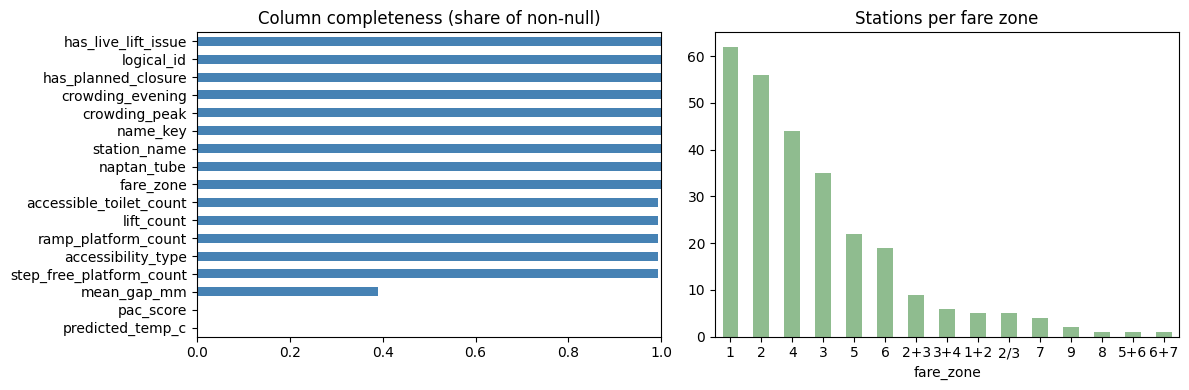


Schema summary:
logical_id                   object
naptan_tube                  object
station_name                 object
name_key                     object
fare_zone                    object
lift_count                  float64
step_free_platform_count    float64
accessible_toilet_count     float64
accessibility_type          float64
ramp_platform_count         float64
mean_gap_mm                 float64
crowding_peak               float64
crowding_evening            float64
has_planned_closure           int64
has_live_lift_issue           int64
predicted_temp_c             object
pac_score                    object
dtype: object


In [ ]:
# ============================================================
# CELL 10: Sanity check | 数据体检
# EN: Run after every rebuild. English-only labels on plots.
# 中文: 每次重建后跑一遍。图表只用英文,避免乱码。
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# EN: completeness per column | 中文: 每列完整度
completeness = attributes_df.notna().mean().sort_values()
completeness.plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Column completeness (share of non-null)')
axes[0].set_xlim(0, 1)

# EN: stations per fare zone | 中文: 各票价区站点数
zone_counts = attributes_df['fare_zone'].fillna('unknown').value_counts()
zone_counts.plot.bar(ax=axes[1], color='darkseagreen')
axes[1].set_title('Stations per fare zone')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("\nSchema summary:")
print(attributes_df.dtypes)

# ❗️【ACTION REQUIRED】Solution for `dtype` in Pandas conversion

In [ ]:
# Solution for `dtype` in Pandas conversion

# TODO [Phase 2, before modelling] fare_zone preprocessing

# Issue: fare_zone is object dtype because of boundary stations ("2+3", "1+2")
# Fix: take the innermost zone (minimum) as the numeric feature


# 待办 [Phase 2 建模前] fare_zone 预处理

# 问题:跨区站("2+3")导致该列是字符串,不能直接当数值特征
# 方案:取最小区号作为数值特征(离市中心最近的那个区)
attributes_df['fare_zone_num'] = (
    attributes_df['fare_zone'].astype(str)
    .str.extract(r'(\d+)')[0]        # first number in the string 取字符串里第一个数字
    .astype(float)
)

# Pilot Study 1 [with dummy data]: Phase 1 → 2 → 3 dry run

**Purpose 目的**: prove the *architecture connects* before real data arrives — the exact fear this addresses is "preprocessing done, but later phases don't fit".
在真实数据到位前验证架构衔接,针对的就是"预处理做完、后面接不上"的担心。

**How it works 原理**: Stage 1 fabricates a table with the **exact Cell 7 schema**. Every later stage consumes only that schema. If the pilot runs on fake data, it runs on real data — the schema is the contract.
阶段 1 伪造一张与 Cell 7 完全同构的表,后续阶段只依赖这个 schema。假数据能跑通,真数据就能跑通 —— schema 就是接口契约。

**What is simulated 模拟的部分**: station values (random), interchange heuristic (until Monday's topology decision), HITL labels (formula + noise, until the real 400 routes).

**Numbers mean nothing 数值无意义** — only the *connections* are being tested. Do not quote the pilot metrics as project results.
只测衔接,不测数值。pilot 的指标不能当作项目结果引用。

Run order: Stage 1 → (1b optional) → 2 → 3 → 4. Total runtime ≈ 30 seconds, 0 API calls.

**Findings** [summarised by Claude]:

The pilot study verified the pipeline end to end :schema, routes, labels, models all connect, fully reproducible — **everything left is data, not design**.

## Stage 1 — Simulate Phase 1 output | 模拟 Phase 1 产出 (exact Cell 7 schema)

In [ ]:
# ============================================================
# PILOT STAGE 1: simulate Phase 1 output
# 阶段 1:模拟 Phase 1 的产出
# Generates a fake attributes_df with the EXACT Cell 7 schema.
# If the pilot runs on this, it will run on the real table too -
# the schema IS the contract between phases.
# 生成与 Cell 7 完全同构的假属性表。pilot 在它上面能跑通,
# 换成真表也一定能跑 —— schema 就是各 phase 之间的接口契约。
# ============================================================
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

N = 272
LINES = ['bakerloo','central','circle','district','hammersmith-city','jubilee',
         'metropolitan','northern','piccadilly','victoria','waterloo-city']

def rand_lines():
    k = rng.choice([1,1,1,2,2,3], p=[.35,.15,.1,.2,.15,.05])
    return ';'.join(sorted(rng.choice(LINES, size=k, replace=False)))

zones_pool = ['1','2','3','4','5','6','2+3','1+2','3+4','7','8','9']
zone_p     = [.23,.20,.13,.16,.08,.07,.03,.02,.02,.03,.02,.01]

stations = pd.DataFrame({
    'naptan_tube': [f'940GZZLU{i:03d}' for i in range(N)],
    'station_name': [f'Station {i}' for i in range(N)],
    'fare_zone': rng.choice(zones_pool, size=N, p=zone_p),
    'line_ids': [rand_lines() for _ in range(N)],
    'lift_count': rng.poisson(2.5, N),
    'step_free_platform_count': rng.poisson(1.8, N),
    'accessible_toilet_count': rng.poisson(0.8, N),
    'accessibility_type': rng.choice([0,1,2,3], size=N, p=[.35,.3,.2,.15]),
    'ramp_platform_count': rng.poisson(0.6, N),
    'mean_gap_mm': rng.normal(90, 25, N).clip(20, 200).round(0),
    'crowding_peak': rng.beta(2.2, 4, N).round(4),
    'crowding_evening': rng.beta(2.0, 4.5, N).round(4),
    'has_planned_closure': rng.choice([0,1], size=N, p=[.9,.1]),
    'has_live_lift_issue': rng.choice([0,1], size=N, p=[.93,.07]),
})

# per-line SARIMA temperature (Monica's approach): temp belongs to the LINE
# 按线路的 SARIMA 温度(Monica 方案):温度是线路属性,不是站点属性
line_temp = {l: t for l, t in zip(LINES, rng.normal(24, 3, len(LINES)).round(1))}
stations['predicted_temp_c'] = stations['line_ids'].map(
    lambda s: round(np.mean([line_temp[l] for l in s.split(';')]), 1))

# fare_zone preprocessing - the TODO found by the Cell 10 sanity check
# fare_zone 预处理 - Cell 10 体检发现的那个待办
stations['fare_zone_num'] = (stations['fare_zone'].astype(str)
                             .str.extract(r'(\d+)')[0].astype(float))

assert len(stations) == 272
print(f"STAGE 1 OK - simulated attributes_df: {stations.shape[0]} rows")
stations.head(3)

STAGE 1 OK - simulated attributes_df: 272 rows


,naptan_tube,station_name,fare_zone,line_ids,lift_count,step_free_platform_count,accessible_toilet_count,accessibility_type,ramp_platform_count,mean_gap_mm,crowding_peak,crowding_evening,has_planned_closure,has_live_lift_issue,predicted_temp_c,fare_zone_num
0,940GZZLU000,Station 0,5,hammersmith-city,2,3,2,1,1,103.0,0.4567,0.1487,0,0,23.5,5.0
1,940GZZLU001,Station 1,3,jubilee;piccadilly,1,1,0,1,1,104.0,0.0679,0.5963,0,0,24.6,3.0
2,940GZZLU002,Station 2,6,waterloo-city,0,3,0,3,0,42.0,0.7153,0.5134,0,0,23.3,6.0


## Stage 1b — [OPTIONAL] Swap in the real frozen snapshot | 可选:换入真实快照 (after Monday)

In [ ]:
# ============================================================
# PILOT STAGE 1b [OPTIONAL]: swap in the REAL frozen snapshot
# 阶段 1b [可选]:换入真实冻结快照
# Run this AFTER Monday's freeze to prove YOUR preprocessing
# connects to the later phases. Skip it to stay on simulated data.
# 周一冻结后运行本格,用你的真实数据验证衔接。跳过则继续用模拟数据。
# ============================================================
USE_REAL_SNAPSHOT = False          # set True after Monday freeze 周一冻结后改 True
REAL_SNAPSHOT_DATE = '2026-07-06'  # match your TRAINING_DATE 与 TRAINING_DATE 一致

if USE_REAL_SNAPSHOT:
    import pathlib
    real_path = pathlib.Path('/content/drive/MyDrive/SKIP/data/snapshots') / \
                f'attributes_{REAL_SNAPSHOT_DATE}.csv'
    real = pd.read_csv(real_path)
    # registry has line_ids in stations_df, not attributes - merge it in
    # line_ids 在身份表里,属性表没有,补进来
    reg = pd.read_csv('/content/drive/MyDrive/SKIP/data/static/station_registry.csv')
    real = real.merge(reg[['naptan_tube', 'line_ids']], on='naptan_tube', how='left')
    # 6 static columns are still NaN until the CSVs arrive -
    # fill with simulated values so the pilot can proceed (clearly marked)
    # 6 个静态列在 CSV 到位前仍为空,先用模拟值填充以便 pilot 继续(明确标注)
    STATIC_COLS = ['lift_count','step_free_platform_count','accessible_toilet_count',
                   'accessibility_type','ramp_platform_count','mean_gap_mm']
    for c in STATIC_COLS:
        if real[c].isna().all():
            real[c] = stations[c].values
            print(f"  [sim-fill] {c} filled with simulated values 用模拟值临时填充")
    real['fare_zone_num'] = (real['fare_zone'].astype(str)
                             .str.extract(r'(\d+)')[0].astype(float))
    real['predicted_temp_c'] = stations['predicted_temp_c'].values  # until SARIMA 等 SARIMA
    stations = real
    print(f"REAL snapshot loaded: {stations.shape[0]} rows - downstream stages unchanged")
else:
    print("Staying on simulated data. 继续使用模拟数据。")

Staying on simulated data. 继续使用模拟数据。


## Stage 2 — Routes from pure lookup | 纯查表生成路线 (0 API calls)

In [ ]:
# ============================================================
# PILOT STAGE 2: route generation + route features
# 阶段 2:路线生成与路线特征(缺失的 Phase 2 层,pilot 先行版)
# 4000 routes from pure local lookup - 0 API calls.
# Route accessibility uses MIN not mean: the worst station breaks the chain.
# 4000 条路线纯本地查表,0 次 API。无障碍特征取 MIN 而非均值:
# 最差的一站决定整条路线是否可用。
# ============================================================
N_ROUTES = 4000
pairs = set()
while len(pairs) < N_ROUTES:
    a, b = rng.integers(0, len(stations), 2)
    if a != b:
        pairs.add((a, b))
pairs = list(pairs)

S = stations.reset_index(drop=True)

def route_features(o_idx, d_idx):
    o, d = S.loc[o_idx], S.loc[d_idx]
    o_lines, d_lines = set(str(o['line_ids']).split(';')), set(str(d['line_ids']).split(';'))
    shared = o_lines & d_lines
    # simplified interchange heuristic - real version comes from the
    # tube graph (Line/Route/Sequence) or Journey API, Monday decision 3
    # 简化换乘启发式 - 正式版来自本地建图或 Journey API(周一决定 3)
    interchanges = 0 if shared else int(rng.choice([1,2], p=[.7,.3]))
    lines_used = sorted(shared)[:1] if shared else sorted(o_lines)[:1] + sorted(d_lines)[:1]
    temps = [line_temp.get(l, 24.0) for l in lines_used]
    return {
        'origin_idx': o_idx, 'dest_idx': d_idx,
        'min_step_free': min(o['step_free_platform_count'], d['step_free_platform_count']),
        'min_accessibility': min(o['accessibility_type'], d['accessibility_type']),
        'max_gap_mm': max(o['mean_gap_mm'], d['mean_gap_mm']),
        'min_lift_count': min(o['lift_count'], d['lift_count']),
        'any_lift_issue': int(bool(o['has_live_lift_issue']) or bool(d['has_live_lift_issue'])),
        'any_closure': int(bool(o['has_planned_closure']) or bool(d['has_planned_closure'])),
        'mean_crowding_peak': (o['crowding_peak'] + d['crowding_peak']) / 2,
        'route_temp': float(np.mean(temps)),
        'num_interchanges': interchanges,
        'zone_span': abs(o['fare_zone_num'] - d['fare_zone_num']),
    }

routes = pd.DataFrame([route_features(a, b) for a, b in pairs])
print(f"STAGE 2 OK - {len(routes)} routes, {routes.shape[1]-2} features, 0 API calls")
routes.head(3)

STAGE 2 OK - 4000 routes, 10 features, 0 API calls


,origin_idx,dest_idx,min_step_free,min_accessibility,max_gap_mm,min_lift_count,any_lift_issue,any_closure,mean_crowding_peak,route_temp,num_interchanges,zone_span
0,92,232,0,1,105.0,4,0,0,0.24660,25.9,1,4.0
1,185,194,1,0,63.0,2,0,1,0.31115,24.8,1,3.0
2,112,210,2,1,125.0,2,0,0,0.31630,23.6,2,2.0


## Stage 3 — PAC formula + simulated HITL labels | 公式打分与模拟人工标注

In [ ]:
# ============================================================
# PILOT STAGE 3: PAC formula score + simulated HITL labels
# 阶段 3:PAC 公式打分 + 模拟人工标注
# The formula alone as a label would be CIRCULAR (the model would just
# re-learn our own formula). Here simulated humans agree ~80-85% with
# the formula; the disagreement stands in for information the formula
# lacks. Real Phase 3 replaces this with the 400 HITL routes.
# 公式直接当标签会造成循环论证。这里模拟人类约 80-85% 同意公式,
# 不同意的部分代表公式之外的信息。正式 Phase 3 用 400 条真人标注替换。
# ============================================================
score = (
      0.40 * (routes['min_accessibility'] / 3)
    + 0.15 * (routes['min_step_free'].clip(0, 4) / 4)
    + 0.15 * (1 - routes['mean_crowding_peak'])
    + 0.10 * (1 - routes['num_interchanges'] / 2)
    + 0.10 * (1 - routes['any_lift_issue'])
    + 0.10 * (1 - routes['any_closure'])
)
routes['pac_formula'] = score.round(4)

human_noise = rng.normal(0, 0.08, len(routes))
routes['pac_human'] = (routes['pac_formula'] + human_noise).clip(0, 1)
routes['label_good'] = (routes['pac_human'] > routes['pac_human'].median()).astype(int)

agree = ((routes['pac_formula'] > routes['pac_formula'].median())
         == routes['label_good']).mean()
print(f"STAGE 3 OK - human-formula agreement 人类与公式一致率: {agree:.0%}")

STAGE 3 OK - human-formula agreement 人类与公式一致率: 80%


## Stage 4 — Models & evaluation | 模型与评估

In [ ]:
# ============================================================
# PILOT STAGE 4: models + evaluation (Sarah's layer)
# 阶段 4:模型与评估(Sarah 的层)
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

FEATURES = ['min_step_free','min_accessibility','max_gap_mm','min_lift_count',
            'any_lift_issue','any_closure','mean_crowding_peak','route_temp',
            'num_interchanges','zone_span']
X = routes[FEATURES].values
y = routes['label_good'].values
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2,
                                      random_state=42, stratify=y)
scaler = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)

lr = LogisticRegression(max_iter=1000, random_state=42).fit(Xtr_s, ytr)
rf = RandomForestClassifier(n_estimators=200, random_state=42).fit(Xtr, ytr)

print("STAGE 4 OK - evaluation on held-out 20%:")
for name, model, Xe in [('LogReg', lr, Xte_s), ('RandomForest', rf, Xte)]:
    pred, proba = model.predict(Xe), model.predict_proba(Xe)[:, 1]
    print(f"  {name:12s} acc={accuracy_score(yte,pred):.3f}  "
          f"prec={precision_score(yte,pred):.3f}  "
          f"rec={recall_score(yte,pred):.3f}  "
          f"f1={f1_score(yte,pred):.3f}  "
          f"auc={roc_auc_score(yte,proba):.3f}")

fi = sorted(zip(FEATURES, rf.feature_importances_), key=lambda x: -x[1])[:5]
print("\n  RF top-5 feature importance:")
for f, v in fi:
    print(f"    {f:22s} {v:.3f}")

print("\nPILOT VERDICT: Phase 1 schema -> routes -> labels -> models, connected.")
print("结论:Phase 1 的 schema 到路线、标签、模型全链路衔接成功。")

STAGE 4 OK - evaluation on held-out 20%:
  LogReg       acc=0.828  prec=0.862  rec=0.780  f1=0.819  auc=0.919
  RandomForest acc=0.809  prec=0.824  rec=0.785  f1=0.804  auc=0.896

  RF top-5 feature importance:
    min_accessibility      0.280
    mean_crowding_peak     0.173
    max_gap_mm             0.124
    route_temp             0.123
    zone_span              0.066

PILOT VERDICT: Phase 1 schema -> routes -> labels -> models, connected.
结论:Phase 1 的 schema 到路线、标签、模型全链路衔接成功。


# # Pilot Study 2 [with snapshot data]

## Phase 2 Prototype: Snapshot → Top-3 Route Recommender

**Goal 目标**: frozen snapshot in, three PAC-ranked routes out — the project's target, running today.
读入冻结快照,输出按 PAC 排序的前 3 条路线 —— 项目目标,今天跑通。

**Prerequisites 前置**: run Cells 1-4 first (api_get, resolve_station, stations_df in memory) and set `TRAINING_DATE`. Then run R1 → R6 in order.
先运行 Cell 1-4 并设置 TRAINING_DATE,然后按序运行 R1 → R6。

**Cost 成本**: R2 builds the tube graph — ~11 API calls once, cached forever. Everything after is 0 calls.
R2 建图约 11 次调用,一次性,永久缓存;之后全部 0 调用。

**Honesty notes 诚实声明**:
- Scoring is currently **formula-based** (3 goal weight sets). The HITL-trained model (Monday decision 1) later plugs into the same interface.
  当前为公式打分,HITL 模型之后以同一接口接入。
- Features backed by empty columns (pending CSVs, SARIMA) are **skipped with weights renormalised** — every recommendation prints what it used vs skipped.
  空列特征自动跳过并重归一权重,每次推荐打印使用/跳过清单。
- Graph edges come from Route/Sequence, so interchange counts are real topology, not heuristics. Durations are not modelled yet (would need Journey API — Monday decision 3).
  换乘数来自真实拓扑;时长尚未建模(需 Journey API,周一决定3)。

## R1 — Load frozen snapshot | 读取冻结快照

Findings:
`naptan_tube` column became `index`

In [ ]:
# ============================================================
# CELL R1: Load the frozen snapshot | 读取冻结快照
# Prerequisite: Cells 1-4 already run (api_get, DATA_DIR,
# resolve_station, stations_df live in memory), TRAINING_DATE set.
# 前置条件:Cell 1-4 已运行(api_get 等已在内存),TRAINING_DATE 已设置。
# ============================================================
snap_stations = pd.read_csv(DATA_DIR / 'snapshots' / f'stations_{TRAINING_DATE}.csv')
snap_attrs    = pd.read_csv(DATA_DIR / 'snapshots' / f'attributes_{TRAINING_DATE}.csv')

# index by primary key for O(1) lookups during scoring
# 按主键建索引,打分时查表为 O(1)
ATTRS = snap_attrs.set_index('naptan_tube')

print(f"Snapshot {TRAINING_DATE} loaded: {len(snap_stations)} stations, "
      f"{ATTRS.shape[1]} attribute columns")
assert len(snap_stations) == 272

Snapshot 2026-07-06 loaded: 272 stations, 16 attribute columns


In [ ]:
print(len(ATTRS))                    # 预期 272
print(ATTRS.index.name)              # 预期 naptan_tube(它在这)
print(ATTRS.loc['940GZZLUGPK', 'station_name'])   # 预期 Green Park...

272
naptan_tube
Green Park Underground Station


## R2 — Build tube graph | 构建地铁网络图 (~11 API calls, once)

In [ ]:
# ============================================================
# CELL R2: Build the tube graph | 构建地铁网络图
# One Route/Sequence call per line (~11 calls total, then cached
# forever). Nodes = stations, edges = adjacent stations on a line,
# edge attribute = which lines connect them.
# 每条线路调一次 Route/Sequence(共约 11 次,之后永久缓存)。
# 节点 = 车站,边 = 线路上相邻的两站,边属性 = 连接它们的线路。
# This is the "local graph" topology option (Monday decision 3) -
# route generation costs 0 API calls once the graph exists.
# 这就是"本地建图"方案(周一决定3)- 图建好后路线生成 0 次调用。
# ============================================================
import networkx as nx

GRAPH_CACHE = DATA_DIR / 'static' / 'tube_graph_edges.csv'
TUBE_LINES = ['bakerloo','central','circle','district','hammersmith-city',
              'jubilee','metropolitan','northern','piccadilly','victoria',
              'waterloo-city']

def build_tube_graph(force=False):
    if GRAPH_CACHE.exists() and not force:
        edges = pd.read_csv(GRAPH_CACHE)
        print(f"Graph edges loaded from disk (0 API calls): {len(edges)} edges. 从本地读取。")
    else:
        rows = []
        for line in TUBE_LINES:
            js = api_get('tfl', f'https://api.tfl.gov.uk/Line/{line}/Route/Sequence/outbound')
            n_seq = 0
            for seq in js.get('stopPointSequences', []):
                stops = [sp['id'] for sp in seq.get('stopPoint', [])
                         if str(sp.get('id','')).startswith('940G')]
                for u, v in zip(stops, stops[1:]):
                    rows.append({'u': u, 'v': v, 'line': line})
                n_seq += 1
            print(f"  {line}: {n_seq} branch sequences")
        edges = pd.DataFrame(rows).drop_duplicates()
        edges.to_csv(GRAPH_CACHE, index=False)
        print(f"Graph built and cached: {len(edges)} edges")

    G = nx.Graph()
    for (u, v), grp in edges.groupby(['u', 'v']):
        lines = set(grp['line'])
        if G.has_edge(u, v):
            G[u][v]['lines'] |= lines
        else:
            G.add_edge(u, v, lines=lines)
    return G

G = build_tube_graph()
print(f"Graph ready: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
# coverage check: how many registry stations are in the graph?
# 覆盖率检查:registry 里有多少站进了图?
in_graph = snap_stations['naptan_tube'].isin(G.nodes).sum()
print(f"Registry coverage: {in_graph}/272 stations present in graph")

Graph edges loaded from disk (0 API calls): 378 edges. 从本地读取。
Graph ready: 272 nodes, 313 edges
Registry coverage: 272/272 stations present in graph


## R3 — Candidate routes | 候选路线生成 (k shortest paths)

In [ ]:
# ============================================================
# CELL R3: Candidate route generation | 候选路线生成
# k shortest simple paths + greedy interchange counting.
# Note: hop-shortest is NOT always best (a shortcut may cost 2
# interchanges) - that is exactly why we keep k candidates and let
# PAC scoring rank them.
# k 条最短简单路径 + 贪心换乘计数。跳数最短不一定最好(抄近道可能
# 多换乘 2 次)- 这正是保留 k 条候选、交给 PAC 打分排序的原因。
# ============================================================
def count_interchanges(G, path):
    """Greedy line-continuation: stay on the current line set while possible.
    贪心延线:能不换线就不换,被迫换线时计一次换乘。"""
    if len(path) < 2:
        return 0, []
    current = set(G[path[0]][path[1]]['lines'])
    lines_used, changes = [], 0
    for u, v in zip(path[1:], path[2:]):
        nxt = set(G[u][v]['lines'])
        stay = current & nxt
        if stay:
            current = stay
        else:
            lines_used.append(sorted(current)[0])
            changes += 1
            current = nxt
    lines_used.append(sorted(current)[0])
    return changes, lines_used

def candidate_routes(origin_name, dest_name, k=5, slack=6):
    """Resolve names -> k candidate paths with topology features.
    站名解析 -> k 条候选路径及其拓扑特征。slack 限制候选不比最短路
    长太多,避免离谱绕路。"""
    o = resolve_station(origin_name)['naptan_tube']
    d = resolve_station(dest_name)['naptan_tube']
    gen = nx.shortest_simple_paths(G, o, d)
    out, shortest_len = [], None
    for path in gen:
        if shortest_len is None:
            shortest_len = len(path)
        if len(path) > shortest_len + slack:
            break
        ic, lines = count_interchanges(G, path)
        out.append({'path': path, 'num_stops': len(path) - 1,
                    'num_interchanges': ic, 'lines_used': lines})
        if len(out) >= k:
            break
    return out

# quick self-test 快速自测
_c = candidate_routes('Green Park', 'Canary Wharf', k=3)
for r in _c:
    print(f"stops={r['num_stops']:2d} interchanges={r['num_interchanges']} "
          f"lines={r['lines_used']}")

stops= 7 interchanges=3 lines=['jubilee', 'waterloo-city', 'northern', 'jubilee']
stops= 7 interchanges=0 lines=['jubilee']
stops= 8 interchanges=5 lines=['jubilee', 'circle', 'bakerloo', 'waterloo-city', 'northern', 'jubilee']


## R4 — Route feature scores | 路线特征分 (NA-aware)

In [ ]:
# ============================================================
# CELL R4: Route feature scores | 路线特征分
# Every score lands in [0,1], 1 = good. Features backed by
# still-empty columns (pending CSVs / SARIMA) return None and are
# SKIPPED - the recommender runs today and gets stronger as data
# arrives, without code changes.
# 每个特征分归一到 [0,1],1 为好。依赖空列(待 CSV/SARIMA)的特征
# 返回 None 并被跳过 - 推荐器今天就能跑,数据补齐后自动变强,零改码。
# ============================================================
def route_feature_scores(route, max_stops):
    st = ATTRS.loc[[s for s in route['path'] if s in ATTRS.index]]
    def col_ok(c):
        return c in st.columns and st[c].notna().all() and len(st) > 0
    return {
        'few_stops': 1 - route['num_stops'] / max(max_stops, 1),
        'few_interchanges': max(0, 1 - route['num_interchanges'] / 3),
        'low_crowding': (1 - st['crowding_peak'].mean()) if col_ok('crowding_peak') else None,
        'no_closure': (1 - st['has_planned_closure'].max()) if col_ok('has_planned_closure') else None,
        'no_lift_issue': (1 - st['has_live_lift_issue'].max()) if col_ok('has_live_lift_issue') else None,
        # min: the worst station breaks the chain 最差一站决定整条路线
        'accessibility_norm': (st['accessibility_type'].astype(float).min() / 3)
                              if col_ok('accessibility_type') else None,
        'small_gap': (1 - st['mean_gap_mm'].astype(float).max() / 200)
                     if col_ok('mean_gap_mm') else None,
        'comfy_temp': (1 - abs(st['predicted_temp_c'].astype(float).mean() - 21) / 15)
                      if col_ok('predicted_temp_c') else None,
    }

## CELL T1 - SARIMA: Carriage Temperature Prediction

In [ ]:
# ============================================================
# CELL T1: SARIMA carriage temperature prediction -> predicted_temp_c
# SARIMA 车厢温度预测 -> 填入 predicted_temp_c
#
# Source: lu-average-monthly-temperatures_2013-2024.csv (monthly,
# per line, 144 months). One SARIMA per line, forecast to 2026-07
# (= TRAINING_DATE month). Station value = max over its serving
# lines (worst case = hottest, same min/worst-aggregation philosophy
# as R4). Sub-surface lines (Circle/District/Metropolitan/H&C)
# share one series, as in the source data.

# 数据源:2013-2024 按线路月度车厢温度。每线一个 SARIMA,预测至
# 2026-07(= 训练日所在月)。站点取所属线路的最高值(最热 = worst
# case,与 R4 的 worst-aggregation 同一哲学)。四条 sub-surface
# 线共用一条序列,与源数据一致。
# ============================================================
import warnings
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX

_matches = list((DATA_DIR / 'static').glob('lu-average-monthly*'))
assert _matches, f"No file matching lu-average-monthly* in {DATA_DIR / 'static'}"
TEMP_CSV = _matches[0]
print(f"Using file 实际使用文件: {TEMP_CSV.name}")
TARGET_MONTH = pd.Timestamp('2026-07-01')   # month of TRAINING_DATE

# ---- 1. Load + tidy | 读取整理 ----
raw = pd.read_csv(TEMP_CSV)
raw = raw.loc[:, ~raw.columns.str.startswith('Unnamed')]
raw = raw.dropna(subset=['Year', 'Month'])
raw.index = pd.to_datetime(raw['Year'].astype(int).astype(str) + ' ' + raw['Month'],
                           format='%Y %B')
temp = raw.drop(columns=['Year', 'Month']).astype(float).asfreq('MS')
print(f"Loaded {temp.shape[0]} months x {temp.shape[1]} lines "
      f"({temp.index[0]:%Y-%m} to {temp.index[-1]:%Y-%m})")

# ---- 2. SARIMA per line, forecast to 2026-07 | 每线预测 ----
steps = (TARGET_MONTH.year - temp.index[-1].year) * 12 \
        + (TARGET_MONTH.month - temp.index[-1].month)
line_temp_2026_07 = {}
print(f"\n{'line':<20}{'SARIMA 2026-07':>15}{'naive Jul mean':>16}{'diff':>7}")
print("-" * 58)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for col in temp.columns:
        series = temp[col].dropna()
        model = SARIMAX(series, order=(1, 0, 0),
                        seasonal_order=(0, 1, 1, 12),
                        enforce_stationarity=False,
                        enforce_invertibility=False).fit(disp=False)
        fc = model.forecast(steps=steps).iloc[-1]
        naive = series[series.index.month == 7].mean()
        line_temp_2026_07[col] = round(float(fc), 1)
        print(f"{col:<20}{fc:>15.1f}{naive:>16.1f}{fc - naive:>7.1f}")

# ---- 3. Map line ids -> CSV columns | 线路 id 映射 ----
LINE_TO_COL = {
    'bakerloo': 'Bakerloo', 'central': 'Central', 'jubilee': 'Jubilee',
    'northern': 'Northern', 'piccadilly': 'Piccadilly', 'victoria': 'Victoria',
    'waterloo-city': 'Waterloo_and_City',
    'circle': 'Sub-surface_lines', 'district': 'Sub-surface_lines',
    'metropolitan': 'Sub-surface_lines', 'hammersmith-city': 'Sub-surface_lines',
}

def station_temp(line_ids):
    temps = [line_temp_2026_07[LINE_TO_COL[l]]
             for l in str(line_ids).split(';') if l in LINE_TO_COL]
    return max(temps) if temps else np.nan   # hottest serving line 最热一条线

temp_map = stations_df.set_index('naptan_tube')['line_ids'].apply(station_temp)
attributes_df['predicted_temp_c'] = attributes_df['naptan_tube'].map(temp_map)

# ---- 4. Verify | 验收 ----
n_filled = attributes_df['predicted_temp_c'].notna().sum()
print(f"\npredicted_temp_c filled: {n_filled}/{len(attributes_df)}")
unmapped = {l for ids in stations_df['line_ids'] for l in str(ids).split(';')
            if l not in LINE_TO_COL}
if unmapped:
    print(f"[warn] unmapped line ids (fell back to NaN) 未映射线路: {unmapped}")
assert n_filled == len(attributes_df), "NOT all stations filled - check line id mapping"
print("CELL T1 OK - snapshot ready for re-freeze 可以重冻")

Using file 实际使用文件: lu-average-monthly-temperatures 2013-2024.csv
Loaded 144 months x 8 lines (2013-01 to 2024-12)

line                 SARIMA 2026-07  naive Jul mean   diff
----------------------------------------------------------
Bakerloo                       30.0            29.9    0.1
Central                        30.1            30.1   -0.0
Jubilee                        25.9            26.0   -0.1
Northern                       27.9            27.8    0.1
Piccadilly                     27.1            27.1    0.0
Victoria                       30.0            28.8    1.2
Waterloo_and_City              24.3            24.3   -0.1
Sub-surface_lines              25.2            25.3   -0.0

predicted_temp_c filled: 272/272
[warn] unmapped line ids (fell back to NaN) 未映射线路: {'w14', '452', 'h10', 'n22', 'h9', 'n19', '397', '22', '137', '167', '667', 'c1', '20', '19', 'n137', '462', '677'}
CELL T1 OK - snapshot ready for re-freeze 可以重冻


## R5 — PAC weights & recommender | PAC 权重与推荐器

In [ ]:
# ============================================================
# CELL R5.v2: PAC goal weights + recommender | PAC 目标权重与推荐器
#
# v2 changes | v2 改动:
#   Corrected goal terminology: PAC = Punctuality / Accessibility / Comfort
# v1 wrongly used 'speed' as the third goal
#   Punctuality is NOT speed: it scores how likely the journey stays
#   undisrupted - closures and interchanges (each transfer is a delay
#   risk point) dominate; journey length matters only as exposure.
#   修正术语:PAC = 准点/无障碍/舒适,v1 误用了 'speed'。
#   准点不等于快:它衡量行程不被打乱的概率 —— 关闭和换乘
#   (每次换乘都是延误风险点)权重最高,路程长短只算暴露度。
#
# Weights over missing features are renormalised; every
# recommendation reports used vs skipped features.
# 缺失特征权重自动重归一,每次推荐报告使用/跳过清单。
# NOTE: formula scoring for now; the HITL-trained model later
# replaces/corrects these scores through the same interface.
# 注意:当前为公式打分,HITL 模型之后以同一接口接入。
# ============================================================
GOAL_WEIGHTS = {
    'punctuality':   {'no_closure': .40, 'few_interchanges': .35,
                      'no_lift_issue': .10, 'few_stops': .15},
    'accessibility': {'accessibility_norm': .30, 'no_lift_issue': .25,
                      'small_gap': .15, 'few_interchanges': .20, 'no_closure': .10},
    'comfort':       {'low_crowding': .40, 'comfy_temp': .20,
                      'few_interchanges': .20, 'no_closure': .20},
}

def pac_score(route, goal, max_stops):
    feats = route_feature_scores(route, max_stops)
    used, skipped, num, den = {}, [], 0.0, 0.0
    for f, w in GOAL_WEIGHTS[goal].items():
        v = feats.get(f)
        if v is None:
            skipped.append(f)
            continue
        used[f] = round(float(v), 3)
        num += w * v
        den += w
    return (num / den if den else 0.0), used, skipped

def recommend(origin, dest, goal='accessibility', k=5, top=3):
    assert goal in GOAL_WEIGHTS, f"goal must be one of {list(GOAL_WEIGHTS)}"
    cands = candidate_routes(origin, dest, k=k)
    if not cands:
        print("No route found. 未找到路线。")
        return []
    max_stops = max(r['num_stops'] for r in cands)
    scored = []
    for r in cands:
        s, used, skipped = pac_score(r, goal, max_stops)
        scored.append({**r, 'pac_score': round(s, 4),
                       'features_used': used, 'features_skipped': skipped})
    scored.sort(key=lambda x: -x['pac_score'])

    print(f"Top {top} routes | goal = {goal} | {origin} -> {dest}")
    print("=" * 62)
    name_of = snap_stations.set_index('naptan_tube')['station_name'].to_dict()
    for rank, r in enumerate(scored[:top], 1):
        names = [name_of.get(s, s).replace(' Underground Station', '')
                 for s in r['path']]
        print(f"#{rank}  PAC {r['pac_score']:.3f} | {r['num_stops']} stops, "
              f"{r['num_interchanges']} interchange(s) | lines: {', '.join(r['lines_used'])}")
        print(f"    {' -> '.join(names)}")
        print(f"    scored on: {r['features_used']}")
    if scored[0]['features_skipped']:
        print(f"\n[transparency] features skipped (data pending): "
              f"{scored[0]['features_skipped']}")
    return scored[:top]

## R6 — DEMO: top-3 under three goals | 演示

In [ ]:
# ============================================================
# CELL R6.v2: DEMO - the three PAC goals, same journey
# 演示:同一行程,PAC 三目标(准点/无障碍/舒适)
# ============================================================
_ = recommend('Green Park', 'Canary Wharf', goal='punctuality')
print()
_ = recommend('Green Park', 'Canary Wharf', goal='accessibility')
print()
_ = recommend('Green Park', 'Canary Wharf', goal='comfort')

Top 3 routes | goal = punctuality | Green Park -> Canary Wharf
#1  PAC 0.883 | 7 stops, 0 interchange(s) | lines: jubilee
    Green Park -> Westminster -> Waterloo -> Southwark -> London Bridge -> Bermondsey -> Canada Water -> Canary Wharf
    scored on: {'no_closure': 1.0, 'few_interchanges': 1.0, 'no_lift_issue': 1.0, 'few_stops': 0.222}
#2  PAC 0.533 | 7 stops, 3 interchange(s) | lines: jubilee, waterloo-city, northern, jubilee
    Green Park -> Westminster -> Waterloo -> Bank -> London Bridge -> Bermondsey -> Canada Water -> Canary Wharf
    scored on: {'no_closure': 1.0, 'few_interchanges': 0.0, 'no_lift_issue': 1.0, 'few_stops': 0.222}
#3  PAC 0.517 | 8 stops, 5 interchange(s) | lines: jubilee, circle, bakerloo, waterloo-city, northern, jubilee
    Green Park -> Westminster -> Embankment -> Waterloo -> Bank -> London Bridge -> Bermondsey -> Canada Water -> Canary Wharf
    scored on: {'no_closure': 1.0, 'few_interchanges': 0.0, 'no_lift_issue': 1.0, 'few_stops': 0.111}

Top 3 rou

# HITL: Manual Label Annotation

In [ ]:
# ============================================================
# CELL L1: HITL labelling sheets - 400 routes + 40 overlap
# HITL 标注表生成 - 400 条路线 + 40 条重叠双标
#
# Zone-stratified OD sampling from the frozen snapshot; top-2
# candidate routes per OD pair; goals rotated evenly; 4 annotators
# x (100 unique + 10 overlap, unmarked). Formula PAC is computed
# but written ONLY to the master key (anti-anchoring); annotator
# sheets show route facts only. 0 API calls (local graph).
# 按 fare zone 分层抽 OD 对,每对取 top-2 候选;goal 均匀轮转;
# 4 名标注者 x(100 独立 + 10 重叠,不标记)。公式 PAC 只写入
# master key(防锚定),标注者表只含路线事实。零 API 调用。
# ============================================================
import random
import numpy as np
import pandas as pd

random.seed(42); np.random.seed(42)

ANNOTATORS = ['TT', 'Sarah', 'Monica', 'Aarna']
GOALS = ['punctuality', 'accessibility', 'comfort']
N_ROUTES, N_OVERLAP = 400, 40
LABEL_DIR = DATA_DIR / 'labelling'
LABEL_DIR.mkdir(exist_ok=True)

# ---- 1. Zone buckets for stratified origins | 分层用 zone 桶 ----
def innermost_zone(z):
    digits = [int(c) for c in str(z) if c.isdigit()]
    return min(digits) if digits else 9

stations = snap_stations.copy()
stations['zone_bucket'] = stations['fare_zone'].apply(innermost_zone).clip(upper=5)
buckets = {z: g['station_name'].tolist() for z, g in stations.groupby('zone_bucket')}
all_names = stations['station_name'].tolist()

# ---- 2. Sample OD pairs -> top-2 routes each | 抽 OD 对,各取 top-2 ----
rows, seen_pairs, bucket_cycle = [], set(), sorted(buckets)
bi = 0
while len(rows) < N_ROUTES:
    origin = random.choice(buckets[bucket_cycle[bi % len(bucket_cycle)]]); bi += 1
    dest = random.choice(all_names)
    if origin == dest or (origin, dest) in seen_pairs:
        continue
    seen_pairs.add((origin, dest))
    try:
        cands = candidate_routes(origin, dest, k=4)
    except Exception:
        continue
    cands = [c for c in cands if c['num_stops'] >= 3][:2]   # skip trivial hops 跳过超短途
    for c in cands:
        if len(rows) < N_ROUTES:
            rows.append({'origin': origin, 'dest': dest, **c})
print(f"Sampled {len(rows)} routes from {len(seen_pairs)} OD pairs 抽样完成")

# ---- 3. Route facts for annotators | 标注者可见的路线事实 ----
name_of = snap_stations.set_index('naptan_tube')['station_name'].to_dict()

def route_facts(r):
    st = ATTRS.loc[[s for s in r['path'] if s in ATTRS.index]]
    def agg(col, fn):
        v = getattr(st[col].dropna(), fn)() if st[col].notna().any() else None
        return round(float(v), 2) if v is not None else ''
    return {
        'path': ' -> '.join(name_of.get(s, s).replace(' Underground Station', '')
                            for s in r['path']),
        'lines': ', '.join(r['lines_used']),
        'num_stops': r['num_stops'],
        'num_interchanges': r['num_interchanges'],
        'worst_step_free_level_0to3': agg('accessibility_type', 'min'),
        'stations_with_live_lift_issue': int(st['has_live_lift_issue'].sum()),
        'planned_closure_on_route_0or1': int(st['has_planned_closure'].max()),
        'peak_crowding_max': agg('crowding_peak', 'max'),
        'forecast_carriage_temp_c_max': agg('predicted_temp_c', 'max'),
        'platform_gap_mm_max': agg('mean_gap_mm', 'max'),
    }

master = []
for i, r in enumerate(rows):
    goal = GOALS[i % len(GOALS)]                      # rotate goals 轮转目标
    s, _, _ = pac_score(r, goal, max(x['num_stops'] for x in rows))
    master.append({'route_id': f'R{i+1:03d}', 'goal': goal,
                   'origin': r['origin'], 'dest': r['dest'],
                   **route_facts(r), 'formula_pac': round(s, 4)})
mdf = pd.DataFrame(master).sample(frac=1, random_state=42).reset_index(drop=True)

# ---- 4. Assign: 100 unique each + 40 overlap balanced | 分配与重叠 ----
mdf['annotator_1'] = [ANNOTATORS[i // 100] for i in range(len(mdf))]
mdf['annotator_2'] = ''
cap = {a: N_OVERLAP // len(ANNOTATORS) for a in ANNOTATORS}   # 10 each
for idx in mdf.sample(frac=1, random_state=7).index:
    if sum(cap.values()) == 0:
        break
    others = [a for a in ANNOTATORS if a != mdf.at[idx, 'annotator_1'] and cap[a] > 0]
    if others and mdf.at[idx, 'annotator_2'] == '':
        pick = max(others, key=lambda a: cap[a])
        mdf.at[idx, 'annotator_2'] = pick
        cap[pick] -= 1

# ---- 5. Write files | 输出 ----
FACT_COLS = ['route_id', 'goal', 'origin', 'dest', 'path', 'lines',
             'num_stops', 'num_interchanges', 'worst_step_free_level_0to3',
             'stations_with_live_lift_issue', 'planned_closure_on_route_0or1',
             'peak_crowding_max', 'forecast_carriage_temp_c_max',
             'platform_gap_mm_max']
for a in ANNOTATORS:
    sheet = mdf[(mdf['annotator_1'] == a) | (mdf['annotator_2'] == a)][FACT_COLS] \
                .sample(frac=1, random_state=1).copy()      # shuffle: overlap unmarked
    sheet['human_label_1to5'] = ''
    sheet['flag'] = ''
    sheet['notes'] = ''
    sheet.to_csv(LABEL_DIR / f'labelling_{a}.csv', index=False)
    print(f"labelling_{a}.csv: {len(sheet)} rows")
mdf.to_csv(LABEL_DIR / 'labelling_master_key.csv', index=False)  # TT only! 仅 TT 保管

# ---- 6. Verify | 验收 ----
assert len(mdf) == N_ROUTES
assert (mdf['annotator_2'] != '').sum() == N_OVERLAP
per = {a: ((mdf['annotator_1'] == a) | (mdf['annotator_2'] == a)).sum() for a in ANNOTATORS}
print(f"Assignments per annotator 每人条数: {per}")
print(f"Goal distribution 目标分布: {mdf['goal'].value_counts().to_dict()}")
assert all(v == 110 for v in per.values())
print("CELL L1 OK - sheets in Drive/SKIP/data/labelling/ 标注表已生成")

Sampled 400 routes from 212 OD pairs 抽样完成
labelling_TT.csv: 110 rows
labelling_Sarah.csv: 110 rows
labelling_Monica.csv: 110 rows
labelling_Aarna.csv: 110 rows
Assignments per annotator 每人条数: {'TT': np.int64(110), 'Sarah': np.int64(110), 'Monica': np.int64(110), 'Aarna': np.int64(110)}
Goal distribution 目标分布: {'punctuality': 134, 'comfort': 133, 'accessibility': 133}
CELL L1 OK - sheets in Drive/SKIP/data/labelling/ 标注表已生成
